# Bước 5 – Huấn Luyện & Đánh Giá (Training & Evaluation)

## Mục tiêu
- Đánh giá tất cả mô hình đã huấn luyện trên tập **test** (dữ liệu model chưa bao giờ thấy)
- Tính đầy đủ **metrics** cho cả bài toán phân loại và hồi quy
- Trực quan hoá: **Confusion Matrix**, **giá dự báo vs thực tế**, **Feature Importance**, **Learning Curve**
- **Nhận xét và chọn mô hình tốt nhất** có lý giải

## Phân chia dữ liệu — BẮT BUỘC dùng TimeSeriesSplit
> **TUYỆT ĐỐI KHÔNG** sử dụng `train_test_split` ngẫu nhiên → gây **data leakage** nghiêm trọng.
- **Train**: 01/01/2020 – 31/12/2024  
- **Test**: 01/01/2025 – hiện tại  
- Cross-validation: `TimeSeriesSplit(n_splits=5)`

## 5.1. Import thư viện và tải dữ liệu

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.preprocessing import StandardScaler

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Đường dẫn
FE_DIR = os.path.join('..', 'data', 'processed', 'feature_engineered')
MODELS_DIR = os.path.join('..', 'models')
OUTPUTS_DIR = os.path.join('..', 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

STOCK_SYMBOLS = ['VCB', 'FPT', 'HPG', 'VIC', 'POW']

# Tên model
CLF_MODELS = ['LogisticRegression', 'RandomForest_Cls', 'XGBoost_Cls']
REG_MODELS = ['RandomForest_Reg', 'XGBoost_Reg']

print("✓ Import thành công")
print(f"Symbols: {STOCK_SYMBOLS}")
print(f"Classification models: {CLF_MODELS}")
print(f"Regression models: {REG_MODELS}")

✓ Import thành công
Symbols: ['VCB', 'FPT', 'HPG', 'VIC', 'POW']
Classification models: ['LogisticRegression', 'RandomForest_Cls', 'XGBoost_Cls']
Regression models: ['RandomForest_Reg', 'XGBoost_Reg']


In [2]:
# === TẢI DỮ LIỆU TRAIN & TEST ===
train_datasets = {}
test_datasets = {}

for symbol in STOCK_SYMBOLS:
    train_path = os.path.join(FE_DIR, symbol, f'{symbol}_train_features.csv')
    test_path = os.path.join(FE_DIR, symbol, f'{symbol}_test_features.csv')
    
    train_df = pd.read_csv(train_path)
    train_df['time'] = pd.to_datetime(train_df['time'])
    train_datasets[symbol] = train_df
    
    test_df = pd.read_csv(test_path)
    test_df['time'] = pd.to_datetime(test_df['time'])
    test_datasets[symbol] = test_df
    
    print(f"✓ {symbol}: Train={train_df.shape} ({train_df['time'].min().date()} → {train_df['time'].max().date()})")
    print(f"         Test ={test_df.shape} ({test_df['time'].min().date()} → {test_df['time'].max().date()})")

# Xác định cột features và targets
exclude_cols = ['time', 'target_cls', 'target_reg']
feature_cols = [col for col in train_datasets['FPT'].columns if col not in exclude_cols]
print(f"\nSố features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

✓ VCB: Train=(1250, 32) (2020-01-02 → 2024-12-31)
         Test =(296, 32) (2025-01-02 → 2026-03-17)
✓ FPT: Train=(1250, 32) (2020-01-02 → 2024-12-31)
         Test =(296, 32) (2025-01-02 → 2026-03-17)
✓ HPG: Train=(1250, 32) (2020-01-02 → 2024-12-31)
         Test =(296, 32) (2025-01-02 → 2026-03-17)
✓ VIC: Train=(1250, 32) (2020-01-02 → 2024-12-31)
         Test =(296, 32) (2025-01-02 → 2026-03-17)
✓ POW: Train=(1250, 32) (2020-01-02 → 2024-12-31)
         Test =(296, 32) (2025-01-02 → 2026-03-17)

Số features: 29
Features: ['open', 'high', 'low', 'close', 'volume', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_histogram', 'BB_upper', 'BB_middle', 'BB_lower', 'daily_return', 'close_lag_1', 'return_lag_1', 'close_lag_3', 'return_lag_3', 'close_lag_7', 'return_lag_7', 'volatility_10', 'volume_sma_10', 'volume_ratio', 'vnindex_return', 'usdvnd_return']


In [3]:
# === TẢI TẤT CẢ MODELS ĐÃ HUẤN LUYỆN ===
models = {}  # {symbol: {model_name: model_object}}
scalers = {}  # {symbol: scaler}

for symbol in STOCK_SYMBOLS:
    models[symbol] = {}
    stock_dir = os.path.join(MODELS_DIR, symbol)
    
    # Tải scaler
    scaler_path = os.path.join(stock_dir, f'{symbol}_feature_scaler.pkl')
    with open(scaler_path, 'rb') as f:
        scalers[symbol] = pickle.load(f)
    
    # Tải classification models
    for model_name in CLF_MODELS:
        model_path = os.path.join(stock_dir, f'{symbol}_{model_name}.pkl')
        with open(model_path, 'rb') as f:
            models[symbol][model_name] = pickle.load(f)
    
    # Tải regression models
    for model_name in REG_MODELS:
        model_path = os.path.join(stock_dir, f'{symbol}_{model_name}.pkl')
        with open(model_path, 'rb') as f:
            models[symbol][model_name] = pickle.load(f)
    
    print(f"✓ {symbol}: Đã tải scaler + {len(CLF_MODELS) + len(REG_MODELS)} models")

# Tải training metadata
with open(os.path.join(MODELS_DIR, 'training_metadata.pkl'), 'rb') as f:
    training_meta = pickle.load(f)

print(f"\n✓ Tổng: {len(STOCK_SYMBOLS) * (len(CLF_MODELS) + len(REG_MODELS))} models đã tải")
print(f"✓ Training metadata đã tải")

✓ VCB: Đã tải scaler + 5 models
✓ FPT: Đã tải scaler + 5 models
✓ HPG: Đã tải scaler + 5 models
✓ VIC: Đã tải scaler + 5 models
✓ POW: Đã tải scaler + 5 models

✓ Tổng: 25 models đã tải
✓ Training metadata đã tải


## 5.2. Đánh giá mô hình Phân Loại (Classification) trên tập Test

### Tại sao dùng TimeSeriesSplit thay vì train_test_split ngẫu nhiên?

Dữ liệu chứng khoán có **tính phụ thuộc thời gian** (autocorrelation). Nếu dùng random split:
- Dữ liệu tương lai có thể lọt vào tập train → model "biết trước" tương lai → **data leakage**
- Kết quả đánh giá sẽ **quá lạc quan**, không phản ánh thực tế

**TimeSeriesSplit** đảm bảo:
- Tập train luôn ở **trước** tập test theo thời gian
- Mô phỏng đúng cách triển khai thực tế: dùng quá khứ dự đoán tương lai

### Metrics phân loại
| Metric | Ý nghĩa |
|--------|---------|
| **Accuracy** | Tỷ lệ dự đoán đúng tổng thể |
| **Precision** | Trong số dự đoán "Tăng", bao nhiêu % đúng? |
| **Recall** | Trong số thực sự "Tăng", model phát hiện được bao nhiêu %? |
| **F1-Score** | Trung bình điều hòa của Precision và Recall |

In [4]:
# === ĐÁNH GIÁ PHÂN LOẠI TRÊN TẬP TEST ===
clf_eval = {}  # {symbol: {model_name: {accuracy, precision, recall, f1, y_true, y_pred}}}

for symbol in STOCK_SYMBOLS:
    print(f"\n{'='*80}")
    print(f"ĐÁNH GIÁ PHÂN LOẠI — {symbol}")
    print(f"{'='*80}")
    
    df_test = test_datasets[symbol]
    X_test = df_test[feature_cols].values
    y_test = df_test['target_cls'].values
    
    # Scale features cho Logistic Regression
    X_test_scaled = scalers[symbol].transform(X_test)
    
    clf_eval[symbol] = {}
    
    for model_name in CLF_MODELS:
        model = models[symbol][model_name]
        
        # Dùng scaled data cho LogisticRegression, raw cho tree-based
        X = X_test_scaled if 'Logistic' in model_name else X_test
        
        y_pred = model.predict(X)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        clf_eval[symbol][model_name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'y_true': y_test,
            'y_pred': y_pred
        }
        
        print(f"\n  --- {model_name} ---")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-Score:  {f1:.4f}")

print(f"\n{'='*80}")
print(f"✓ Đánh giá phân loại hoàn tất cho {len(STOCK_SYMBOLS)} mã × {len(CLF_MODELS)} models")


ĐÁNH GIÁ PHÂN LOẠI — VCB

  --- LogisticRegression ---
  Accuracy:  0.5709
  Precision: 0.5272
  Recall:    0.5709
  F1-Score:  0.4703

  --- RandomForest_Cls ---
  Accuracy:  0.5541
  Precision: 0.5332
  Recall:    0.5541
  F1-Score:  0.5302

  --- XGBoost_Cls ---
  Accuracy:  0.5338
  Precision: 0.5129
  Recall:    0.5338
  F1-Score:  0.5138

ĐÁNH GIÁ PHÂN LOẠI — FPT

  --- LogisticRegression ---
  Accuracy:  0.5034
  Precision: 0.6296
  Recall:    0.5034
  F1-Score:  0.4279

  --- RandomForest_Cls ---
  Accuracy:  0.4831
  Precision: 0.5913
  Recall:    0.4831
  F1-Score:  0.3978

  --- XGBoost_Cls ---
  Accuracy:  0.4696
  Precision: 0.5213
  Recall:    0.4696
  F1-Score:  0.4157

ĐÁNH GIÁ PHÂN LOẠI — HPG

  --- LogisticRegression ---
  Accuracy:  0.5642
  Precision: 0.5867
  Recall:    0.5642
  F1-Score:  0.4617

  --- RandomForest_Cls ---
  Accuracy:  0.5270
  Precision: 0.5141
  Recall:    0.5270
  F1-Score:  0.5088

  --- XGBoost_Cls ---
  Accuracy:  0.5304
  Precision: 0.5205

In [5]:
# === BẢNG TỔNG HỢP METRICS PHÂN LOẠI ===
print("=" * 100)
print("BẢNG TỔNG HỢP — METRICS PHÂN LOẠI TRÊN TẬP TEST")
print("=" * 100)

# Tạo DataFrame tổng hợp
clf_rows = []
for symbol in STOCK_SYMBOLS:
    for model_name in CLF_MODELS:
        r = clf_eval[symbol][model_name]
        clf_rows.append({
            'Mã CP': symbol,
            'Model': model_name,
            'Accuracy': r['accuracy'],
            'Precision': r['precision'],
            'Recall': r['recall'],
            'F1-Score': r['f1']
        })

clf_summary_df = pd.DataFrame(clf_rows)

# Hiển thị bảng đẹp
for symbol in STOCK_SYMBOLS:
    sub = clf_summary_df[clf_summary_df['Mã CP'] == symbol]
    print(f"\n--- {symbol} ---")
    print(sub[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string(index=False, float_format='%.4f'))

# So sánh CV score (train) vs Test score → kiểm tra overfitting
print(f"\n{'='*100}")
print("SO SÁNH CV SCORE (TRAIN) vs TEST SCORE → Kiểm tra Overfitting")
print("=" * 100)
print(f"\n{'Mã CP':8s} {'Model':25s} {'CV Acc (Train)':>15s} {'Test Acc':>10s} {'Chênh lệch':>12s} {'Đánh giá':>15s}")
print("-" * 90)

for symbol in STOCK_SYMBOLS:
    for model_name in CLF_MODELS:
        cv_score = training_meta['clf_scores'][symbol].get(model_name, 0)
        test_score = clf_eval[symbol][model_name]['accuracy']
        gap = cv_score - test_score
        
        if gap > 0.10:
            status = "⚠ Overfitting"
        elif gap > 0.05:
            status = "~ Moderate"
        elif gap < -0.03:
            status = "★ Test > CV"
        else:
            status = "✓ Tốt"
        
        print(f"{symbol:8s} {model_name:25s} {cv_score:15.4f} {test_score:10.4f} {gap:12.4f} {status:>15s}")

BẢNG TỔNG HỢP — METRICS PHÂN LOẠI TRÊN TẬP TEST

--- VCB ---
             Model  Accuracy  Precision  Recall  F1-Score
LogisticRegression    0.5709     0.5272  0.5709    0.4703
  RandomForest_Cls    0.5541     0.5332  0.5541    0.5302
       XGBoost_Cls    0.5338     0.5129  0.5338    0.5138

--- FPT ---
             Model  Accuracy  Precision  Recall  F1-Score
LogisticRegression    0.5034     0.6296  0.5034    0.4279
  RandomForest_Cls    0.4831     0.5913  0.4831    0.3978
       XGBoost_Cls    0.4696     0.5213  0.4696    0.4157

--- HPG ---
             Model  Accuracy  Precision  Recall  F1-Score
LogisticRegression    0.5642     0.5867  0.5642    0.4617
  RandomForest_Cls    0.5270     0.5141  0.5270    0.5088
       XGBoost_Cls    0.5304     0.5205  0.5304    0.5180

--- VIC ---
             Model  Accuracy  Precision  Recall  F1-Score
LogisticRegression    0.4662     0.5718  0.4662    0.3397
  RandomForest_Cls    0.4595     0.5706  0.4595    0.3166
       XGBoost_Cls    0.4426  

## 5.3. Trực quan hóa — Confusion Matrix (Phân loại)

Confusion Matrix cho thấy:
- **True Positive (TP)**: Dự đoán Tăng → Thực tế Tăng ✓
- **True Negative (TN)**: Dự đoán Giảm → Thực tế Giảm ✓
- **False Positive (FP)**: Dự đoán Tăng → Thực tế Giảm ✗
- **False Negative (FN)**: Dự đoán Giảm → Thực tế Tăng ✗

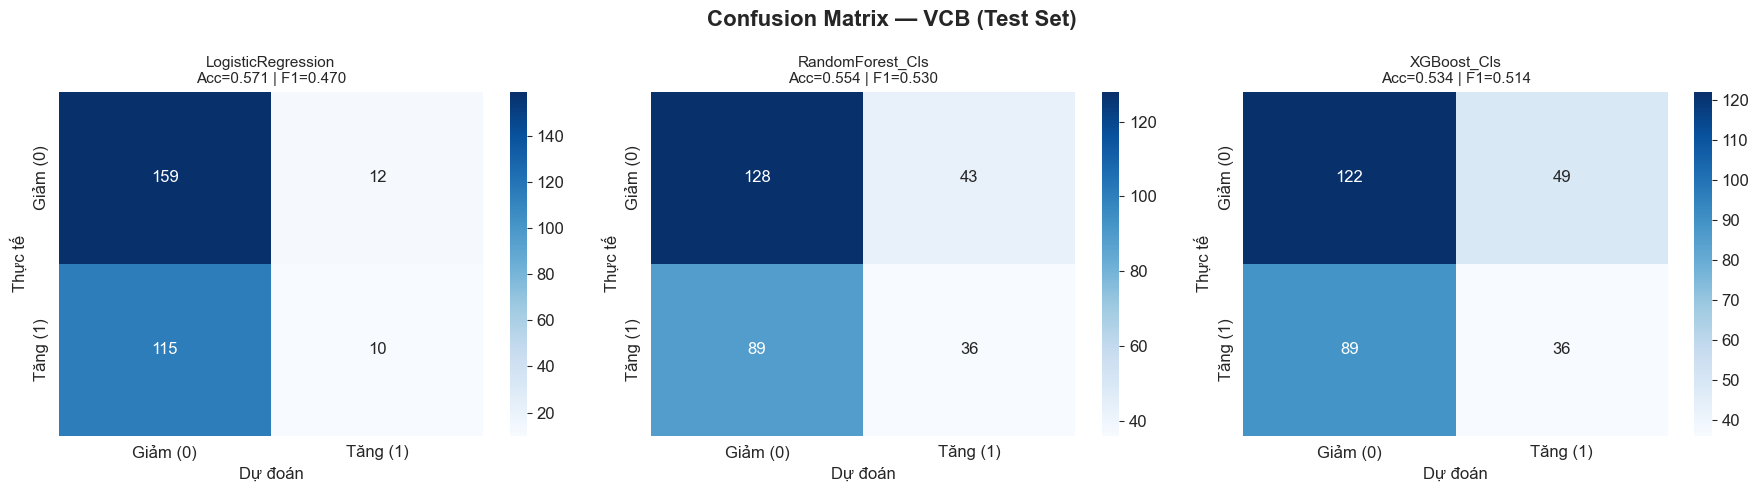


--- Classification Report — VCB (Model tốt nhất) ---
Model tốt nhất: RandomForest_Cls
              precision    recall  f1-score   support

    Giảm (0)       0.59      0.75      0.66       171
    Tăng (1)       0.46      0.29      0.35       125

    accuracy                           0.55       296
   macro avg       0.52      0.52      0.51       296
weighted avg       0.53      0.55      0.53       296




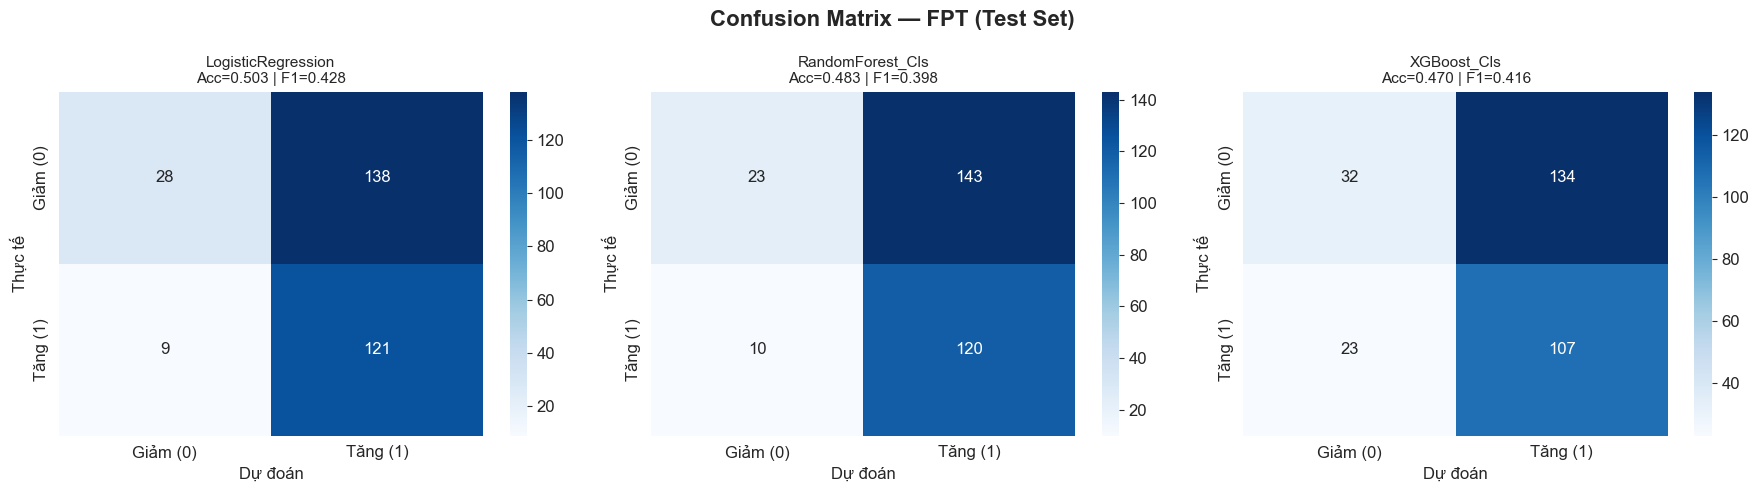


--- Classification Report — FPT (Model tốt nhất) ---
Model tốt nhất: LogisticRegression
              precision    recall  f1-score   support

    Giảm (0)       0.76      0.17      0.28       166
    Tăng (1)       0.47      0.93      0.62       130

    accuracy                           0.50       296
   macro avg       0.61      0.55      0.45       296
weighted avg       0.63      0.50      0.43       296




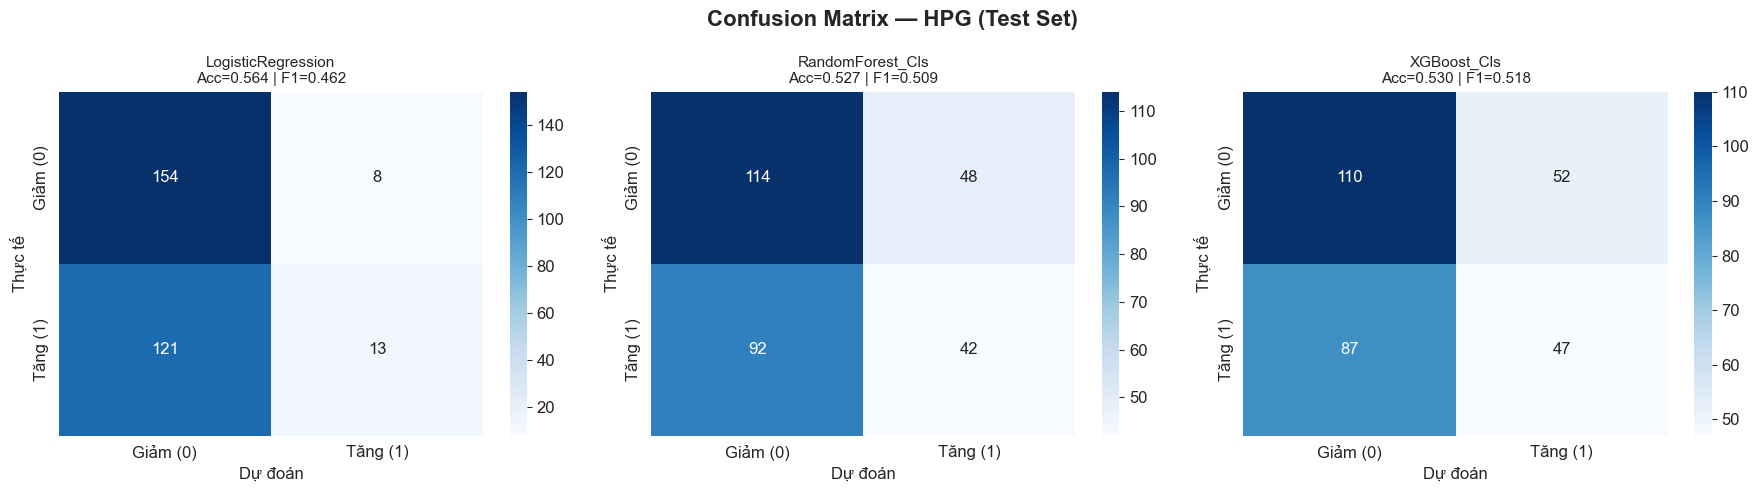


--- Classification Report — HPG (Model tốt nhất) ---
Model tốt nhất: XGBoost_Cls
              precision    recall  f1-score   support

    Giảm (0)       0.56      0.68      0.61       162
    Tăng (1)       0.47      0.35      0.40       134

    accuracy                           0.53       296
   macro avg       0.52      0.51      0.51       296
weighted avg       0.52      0.53      0.52       296




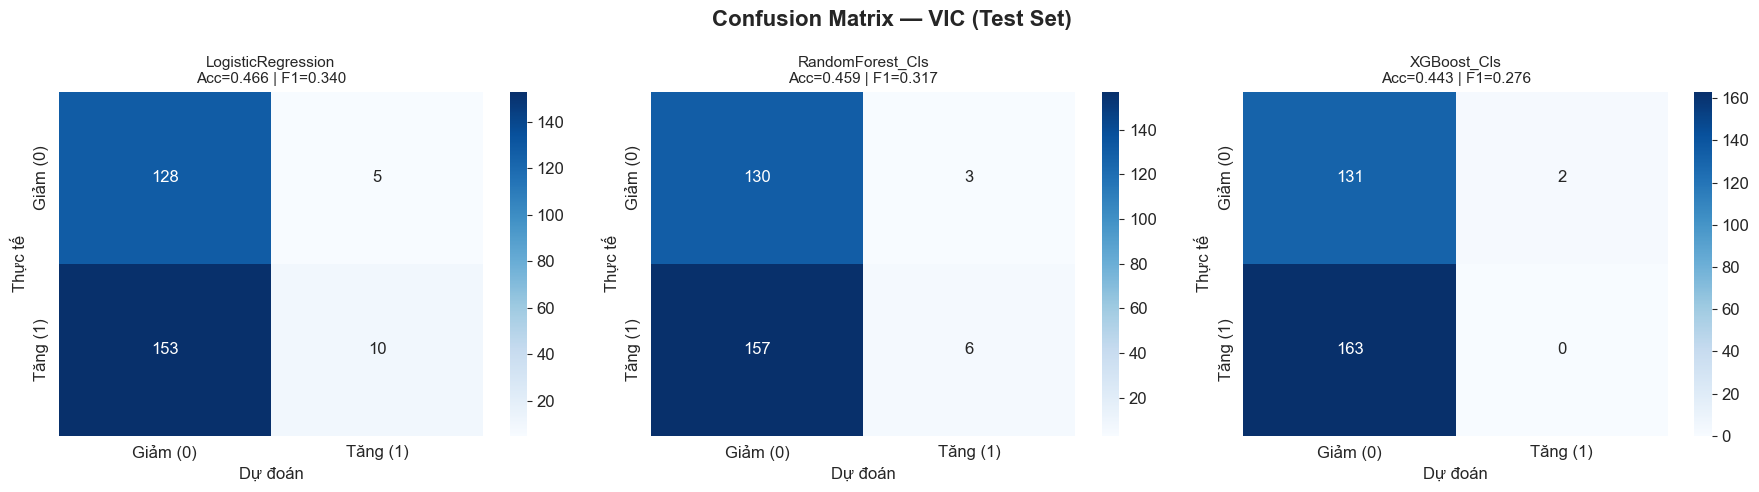


--- Classification Report — VIC (Model tốt nhất) ---
Model tốt nhất: LogisticRegression
              precision    recall  f1-score   support

    Giảm (0)       0.46      0.96      0.62       133
    Tăng (1)       0.67      0.06      0.11       163

    accuracy                           0.47       296
   macro avg       0.56      0.51      0.37       296
weighted avg       0.57      0.47      0.34       296




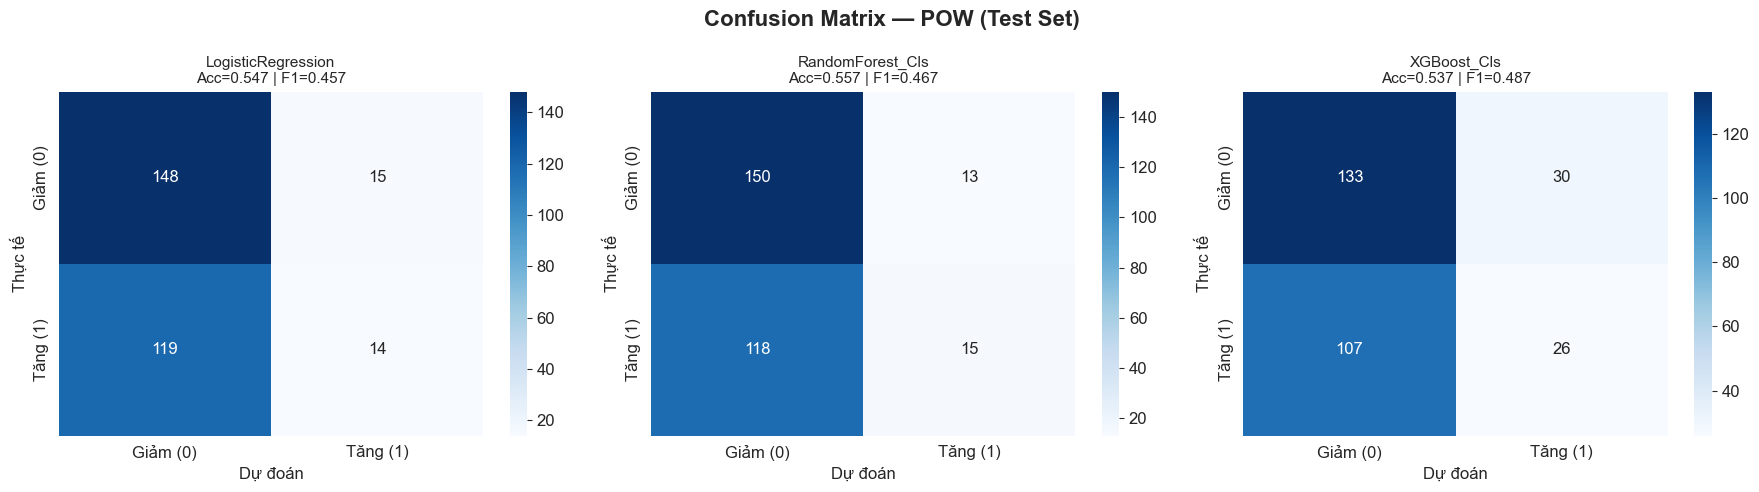


--- Classification Report — POW (Model tốt nhất) ---
Model tốt nhất: XGBoost_Cls
              precision    recall  f1-score   support

    Giảm (0)       0.55      0.82      0.66       163
    Tăng (1)       0.46      0.20      0.28       133

    accuracy                           0.54       296
   macro avg       0.51      0.51      0.47       296
weighted avg       0.51      0.54      0.49       296




In [6]:
# === CONFUSION MATRIX CHO TẤT CẢ MÃ VÀ MODEL ===
for symbol in STOCK_SYMBOLS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrix — {symbol} (Test Set)', fontsize=16, fontweight='bold')
    
    for idx, model_name in enumerate(CLF_MODELS):
        ax = axes[idx]
        y_true = clf_eval[symbol][model_name]['y_true']
        y_pred = clf_eval[symbol][model_name]['y_pred']
        
        cm = confusion_matrix(y_true, y_pred)
        
        # Vẽ heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Giảm (0)', 'Tăng (1)'],
                    yticklabels=['Giảm (0)', 'Tăng (1)'])
        
        acc = clf_eval[symbol][model_name]['accuracy']
        f1 = clf_eval[symbol][model_name]['f1']
        ax.set_title(f'{model_name}\nAcc={acc:.3f} | F1={f1:.3f}', fontsize=11)
        ax.set_xlabel('Dự đoán')
        ax.set_ylabel('Thực tế')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, f'{symbol}_confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Classification Report chi tiết
    print(f"\n--- Classification Report — {symbol} (Model tốt nhất) ---")
    best_model = max(CLF_MODELS, key=lambda m: clf_eval[symbol][m]['f1'])
    print(f"Model tốt nhất: {best_model}")
    print(classification_report(
        clf_eval[symbol][best_model]['y_true'],
        clf_eval[symbol][best_model]['y_pred'],
        target_names=['Giảm (0)', 'Tăng (1)']
    ))
    print()

## 5.4. Đánh giá mô hình Hồi Quy (Regression) trên tập Test

### Metrics hồi quy
| Metric | Công thức | Ý nghĩa |
|--------|-----------|---------|
| **MSE** | (1/n)∑(yi - ŷi)² | Sai số bình phương trung bình — phạt sai số lớn nặng hơn |
| **MAE** | (1/n)∑\|yi - ŷi\| | Sai số tuyệt đối trung bình — dễ diễn giải hơn |
| **RMSE** | √MSE | Cùng đơn vị với biến mục tiêu (VND/nghìn đồng) |
| **R²** | 1 - SS_res/SS_tot | Tỷ lệ phương sai được giải thích (1.0 = hoàn hảo) |

In [7]:
# === ĐÁNH GIÁ HỒI QUY TRÊN TẬP TEST ===
reg_eval = {}  # {symbol: {model_name: {mse, mae, rmse, r2, y_true, y_pred, dates}}}

for symbol in STOCK_SYMBOLS:
    print(f"\n{'='*80}")
    print(f"ĐÁNH GIÁ HỒI QUY — {symbol}")
    print(f"{'='*80}")
    
    df_test = test_datasets[symbol]
    X_test = df_test[feature_cols].values
    y_test = df_test['target_reg'].values
    dates = df_test['time'].values
    
    reg_eval[symbol] = {}
    
    for model_name in REG_MODELS:
        model = models[symbol][model_name]
        y_pred = model.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Tính MAPE (Mean Absolute Percentage Error)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        
        reg_eval[symbol][model_name] = {
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'mape': mape,
            'y_true': y_test,
            'y_pred': y_pred,
            'dates': dates
        }
        
        print(f"\n  --- {model_name} ---")
        print(f"  MSE:  {mse:.4f}")
        print(f"  MAE:  {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  R²:   {r2:.4f}")
        print(f"  MAPE: {mape:.2f}%")

print(f"\n{'='*80}")
print(f"✓ Đánh giá hồi quy hoàn tất cho {len(STOCK_SYMBOLS)} mã × {len(REG_MODELS)} models")


ĐÁNH GIÁ HỒI QUY — VCB

  --- RandomForest_Reg ---
  MSE:  6.1117
  MAE:  1.3224
  RMSE: 2.4722
  R²:   0.6375
  MAPE: 2.01%

  --- XGBoost_Reg ---
  MSE:  6.4351
  MAE:  1.3602
  RMSE: 2.5368
  R²:   0.6183
  MAPE: 2.08%

ĐÁNH GIÁ HỒI QUY — FPT

  --- RandomForest_Reg ---
  MSE:  24.3833
  MAE:  3.7042
  RMSE: 4.9379
  R²:   0.7904
  MAPE: 3.76%

  --- XGBoost_Reg ---
  MSE:  9.3443
  MAE:  2.3126
  RMSE: 3.0569
  R²:   0.9197
  MAPE: 2.32%

ĐÁNH GIÁ HỒI QUY — HPG

  --- RandomForest_Reg ---
  MSE:  0.2850
  MAE:  0.3780
  RMSE: 0.5338
  R²:   0.9630
  MAPE: 1.50%

  --- XGBoost_Reg ---
  MSE:  0.3457
  MAE:  0.4087
  RMSE: 0.5880
  R²:   0.9552
  MAPE: 1.62%

ĐÁNH GIÁ HỒI QUY — VIC

  --- RandomForest_Reg ---
  MSE:  2422.1235
  MAE:  29.9679
  RMSE: 49.2151
  R²:   0.0269
  MAPE: 22.87%

  --- XGBoost_Reg ---
  MSE:  2426.2483
  MAE:  30.0597
  RMSE: 49.2570
  R²:   0.0252
  MAPE: 23.10%

ĐÁNH GIÁ HỒI QUY — POW

  --- RandomForest_Reg ---
  MSE:  0.1048
  MAE:  0.2356
  RMSE: 0.323

In [8]:
# === BẢNG TỔNG HỢP METRICS HỒI QUY ===
print("=" * 110)
print("BẢNG TỔNG HỢP — METRICS HỒI QUY TRÊN TẬP TEST")
print("=" * 110)

reg_rows = []
for symbol in STOCK_SYMBOLS:
    for model_name in REG_MODELS:
        r = reg_eval[symbol][model_name]
        reg_rows.append({
            'Mã CP': symbol,
            'Model': model_name,
            'MSE': r['mse'],
            'MAE': r['mae'],
            'RMSE': r['rmse'],
            'R²': r['r2'],
            'MAPE (%)': r['mape']
        })

reg_summary_df = pd.DataFrame(reg_rows)

for symbol in STOCK_SYMBOLS:
    sub = reg_summary_df[reg_summary_df['Mã CP'] == symbol]
    print(f"\n--- {symbol} ---")
    print(sub[['Model', 'MSE', 'MAE', 'RMSE', 'R²', 'MAPE (%)']].to_string(index=False, float_format='%.4f'))

# So sánh CV RMSE vs Test RMSE
print(f"\n{'='*110}")
print("SO SÁNH CV RMSE (TRAIN) vs TEST RMSE → Kiểm tra Generalization")
print("=" * 110)
print(f"\n{'Mã CP':8s} {'Model':25s} {'CV RMSE':>12s} {'Test RMSE':>12s} {'Chênh lệch':>12s} {'Đánh giá':>15s}")
print("-" * 90)

for symbol in STOCK_SYMBOLS:
    for model_name in REG_MODELS:
        cv_rmse = training_meta['reg_scores'][symbol].get(model_name, 0)
        test_rmse = reg_eval[symbol][model_name]['rmse']
        gap = test_rmse - cv_rmse
        ratio = test_rmse / cv_rmse if cv_rmse > 0 else 999
        
        if ratio > 1.5:
            status = "⚠ Overfitting"
        elif ratio > 1.2:
            status = "~ Moderate"
        else:
            status = "✓ Tốt"
        
        print(f"{symbol:8s} {model_name:25s} {cv_rmse:12.4f} {test_rmse:12.4f} {gap:12.4f} {status:>15s}")

BẢNG TỔNG HỢP — METRICS HỒI QUY TRÊN TẬP TEST

--- VCB ---
           Model    MSE    MAE   RMSE     R²  MAPE (%)
RandomForest_Reg 6.1117 1.3224 2.4722 0.6375    2.0138
     XGBoost_Reg 6.4351 1.3602 2.5368 0.6183    2.0763

--- FPT ---
           Model     MSE    MAE   RMSE     R²  MAPE (%)
RandomForest_Reg 24.3833 3.7042 4.9379 0.7904    3.7586
     XGBoost_Reg  9.3443 2.3126 3.0569 0.9197    2.3193

--- HPG ---
           Model    MSE    MAE   RMSE     R²  MAPE (%)
RandomForest_Reg 0.2850 0.3780 0.5338 0.9630    1.5023
     XGBoost_Reg 0.3457 0.4087 0.5880 0.9552    1.6151

--- VIC ---
           Model       MSE     MAE    RMSE     R²  MAPE (%)
RandomForest_Reg 2422.1235 29.9679 49.2151 0.0269   22.8697
     XGBoost_Reg 2426.2483 30.0597 49.2570 0.0252   23.0988

--- POW ---
           Model    MSE    MAE   RMSE     R²  MAPE (%)
RandomForest_Reg 0.1048 0.2356 0.3238 0.9540    1.9596
     XGBoost_Reg 0.1088 0.2461 0.3298 0.9522    2.0588

SO SÁNH CV RMSE (TRAIN) vs TEST RMSE → Kiểm t

## 5.5. Biểu đồ Giá Dự Báo vs Giá Thực Tế (Regression)

Biểu đồ này trực quan hóa khả năng dự báo giá cổ phiếu ngày t+1 của mô hình hồi quy:
- **Đường xanh**: Giá thực tế
- **Đường đỏ/cam**: Giá dự báo của model
- Model tốt → 2 đường càng sát nhau

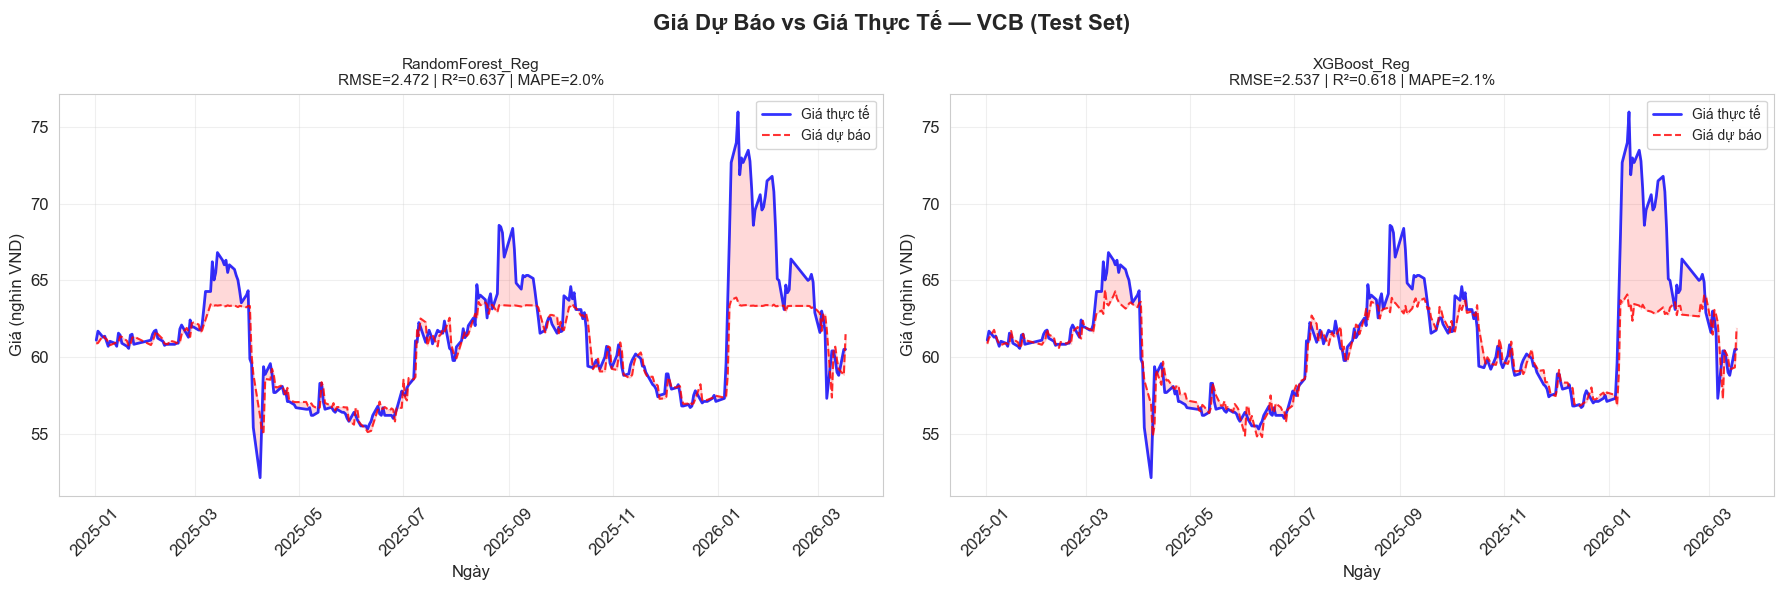

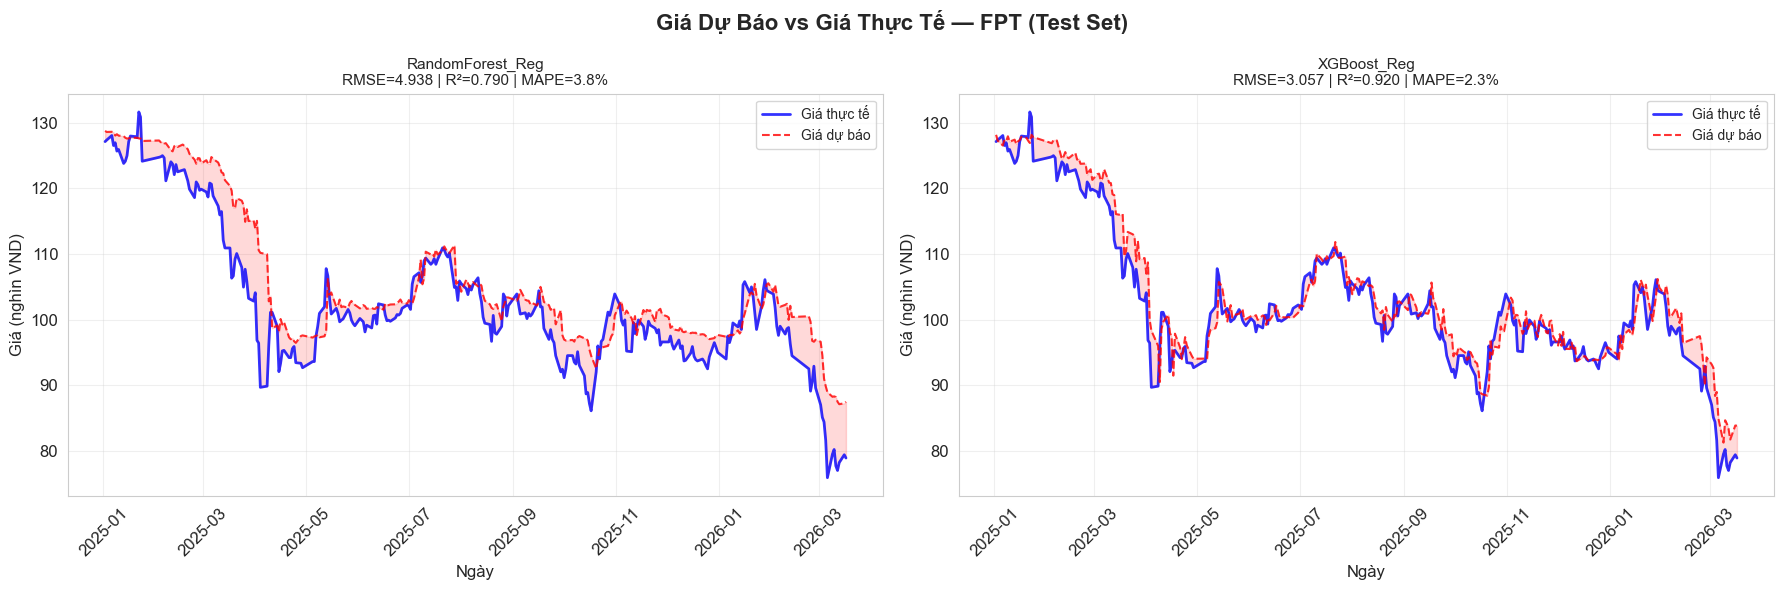

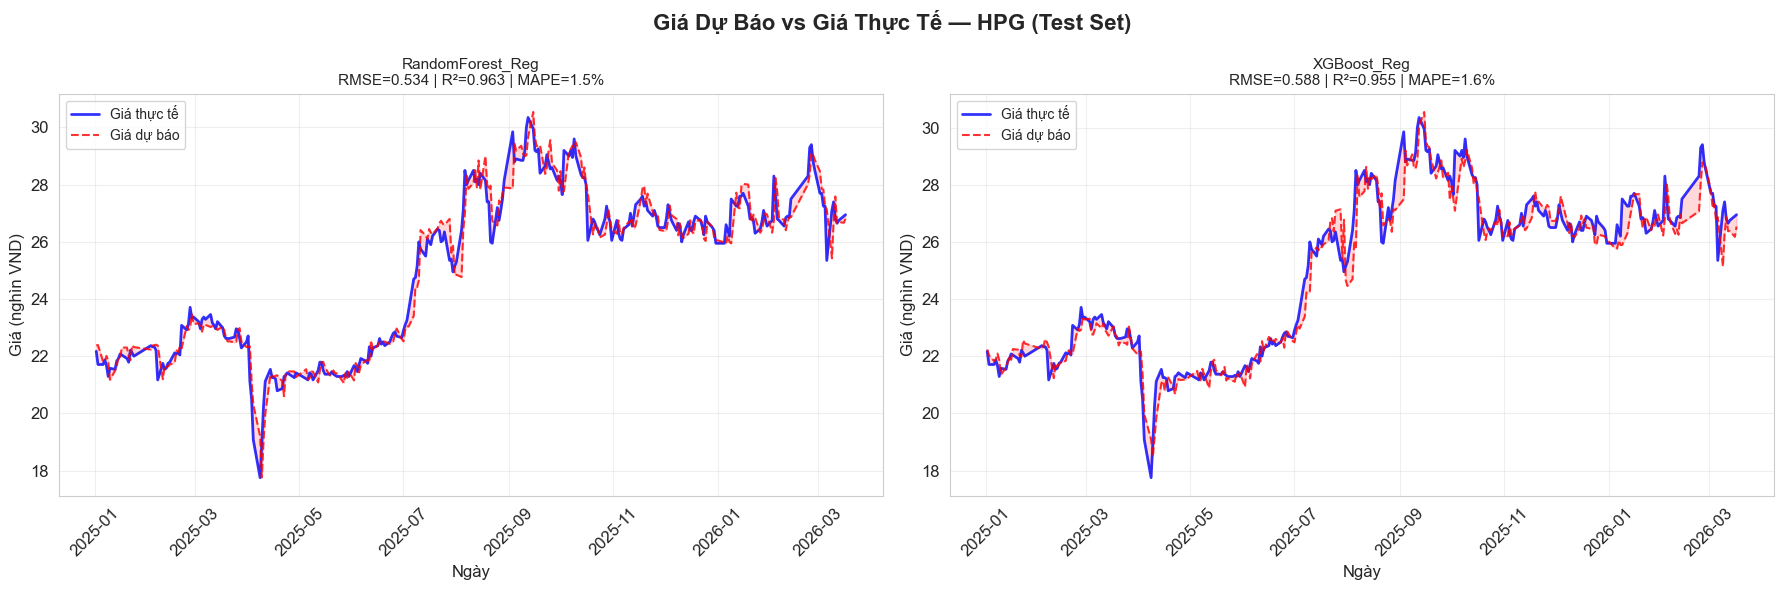

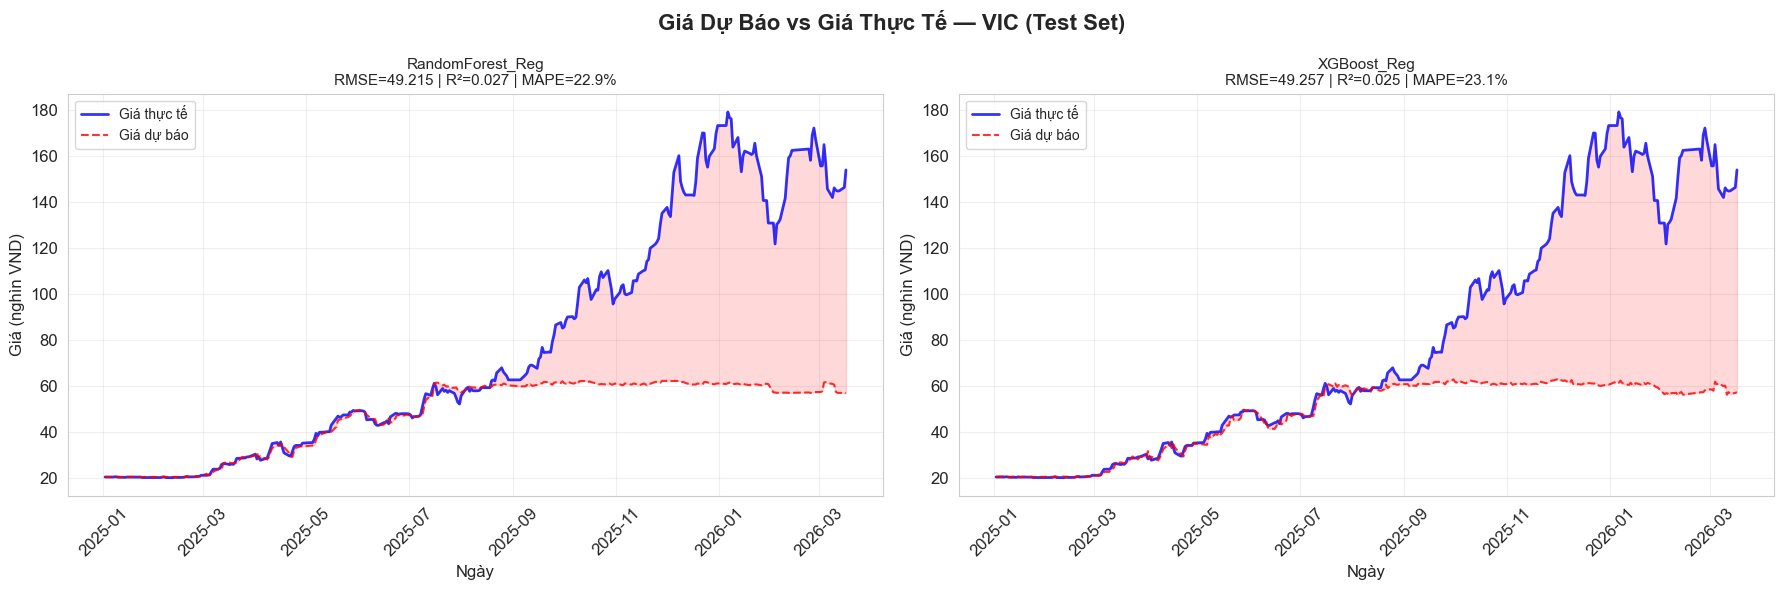

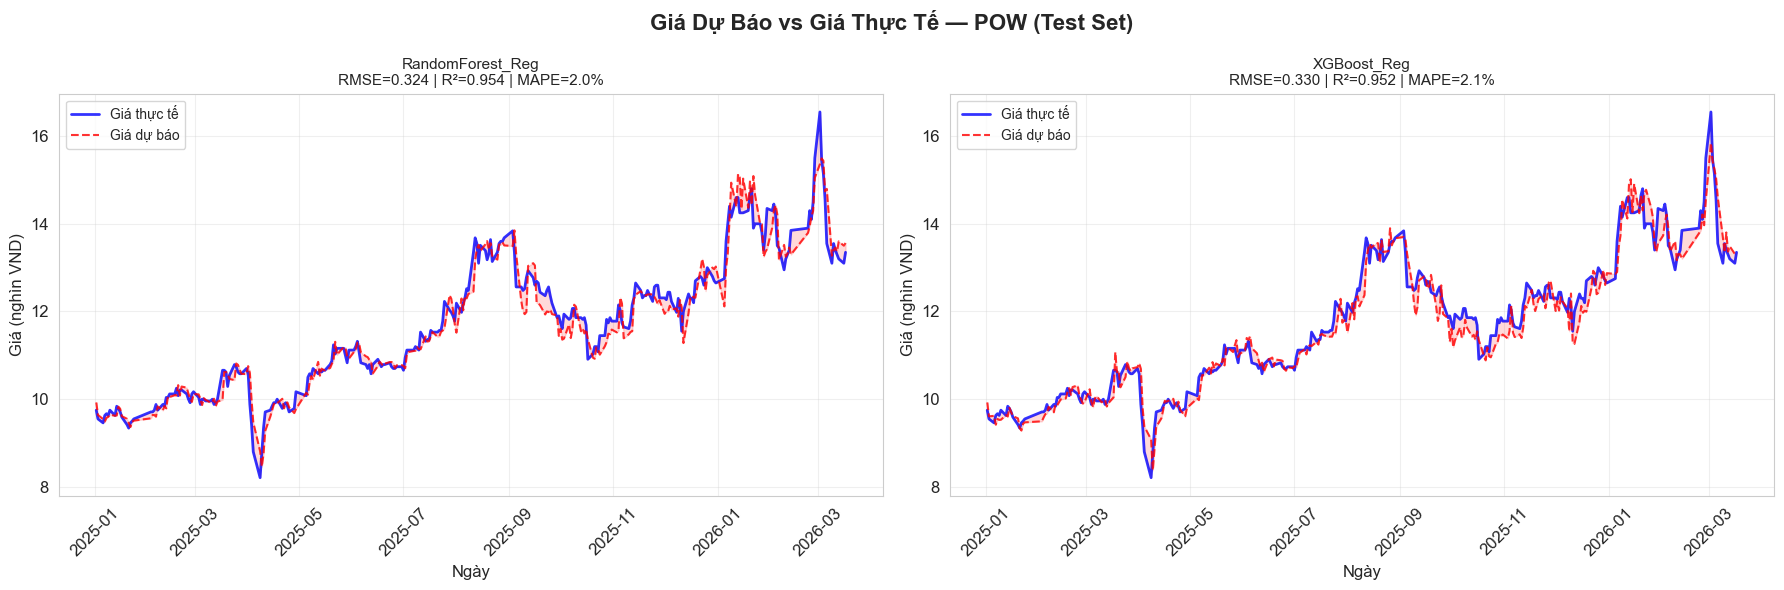

In [9]:
# === BIỂU ĐỒ GIÁ DỰ BÁO vs GIÁ THỰC TẾ ===
for symbol in STOCK_SYMBOLS:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'Giá Dự Báo vs Giá Thực Tế — {symbol} (Test Set)', fontsize=16, fontweight='bold')
    
    for idx, model_name in enumerate(REG_MODELS):
        ax = axes[idx]
        r = reg_eval[symbol][model_name]
        dates = pd.to_datetime(r['dates'])
        
        ax.plot(dates, r['y_true'], label='Giá thực tế', color='blue', linewidth=2, alpha=0.8)
        ax.plot(dates, r['y_pred'], label='Giá dự báo', color='red', linewidth=1.5, linestyle='--', alpha=0.8)
        
        # Tô vùng sai số
        ax.fill_between(dates, r['y_true'], r['y_pred'], alpha=0.15, color='red')
        
        ax.set_title(f'{model_name}\nRMSE={r["rmse"]:.3f} | R²={r["r2"]:.3f} | MAPE={r["mape"]:.1f}%', fontsize=11)
        ax.set_xlabel('Ngày')
        ax.set_ylabel('Giá (nghìn VND)')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, f'{symbol}_price_prediction.png'), dpi=150, bbox_inches='tight')
    plt.show()

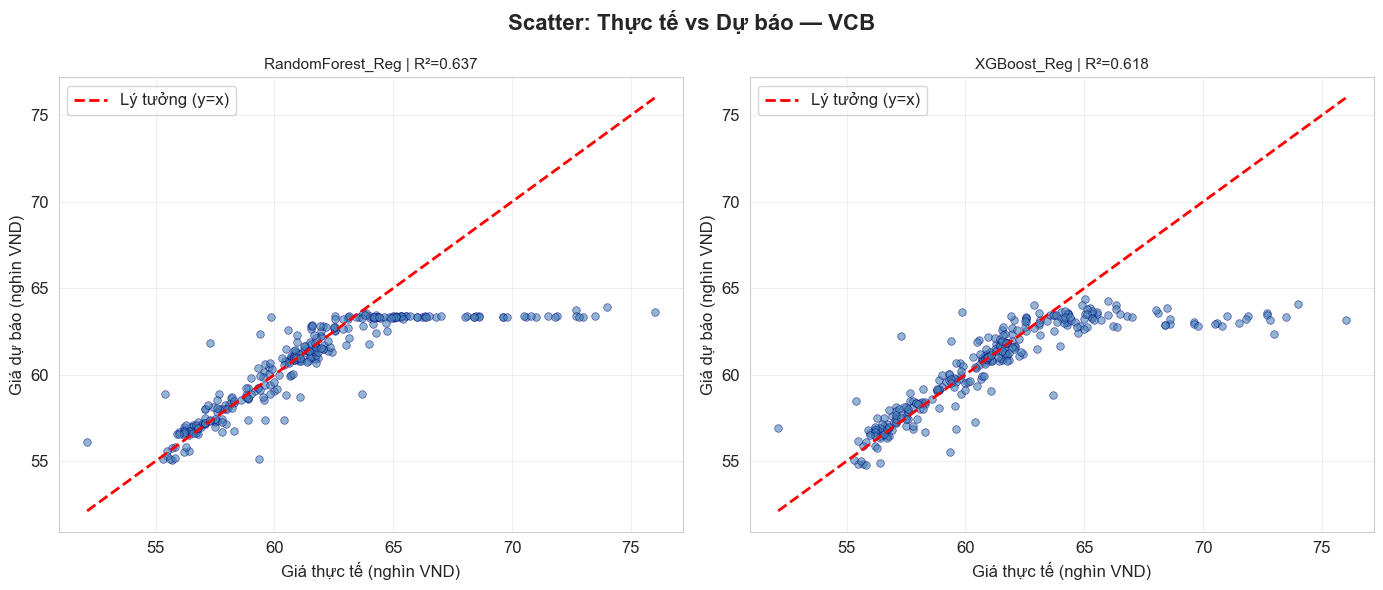

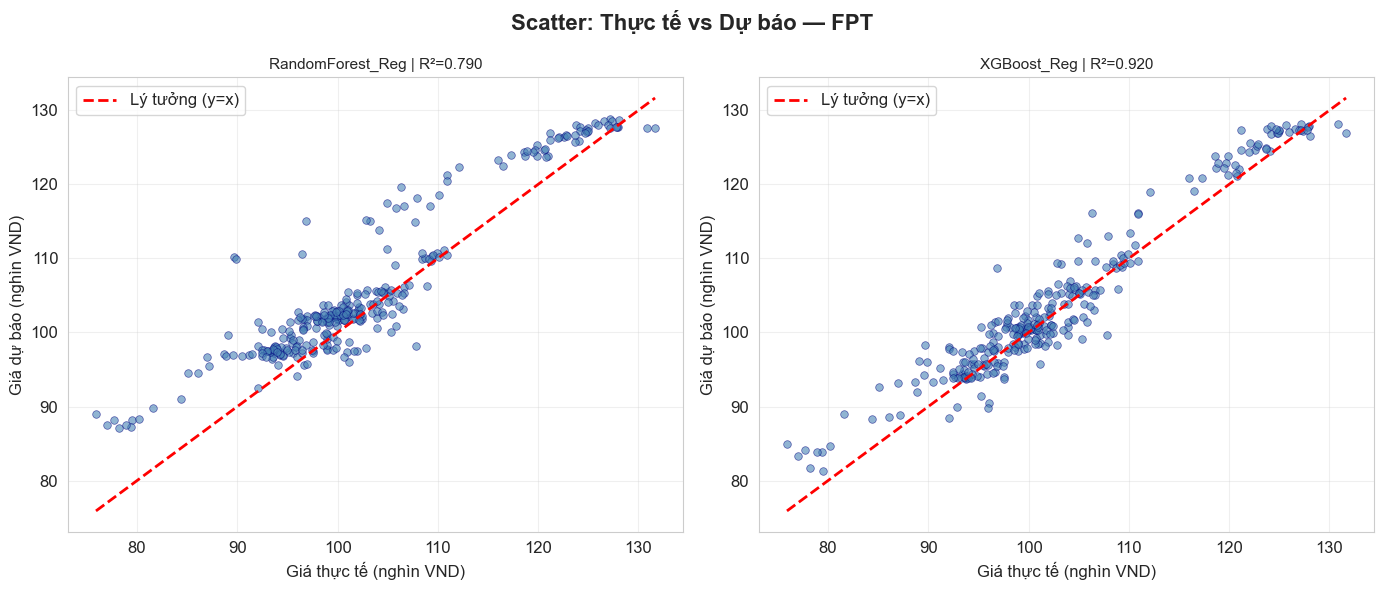

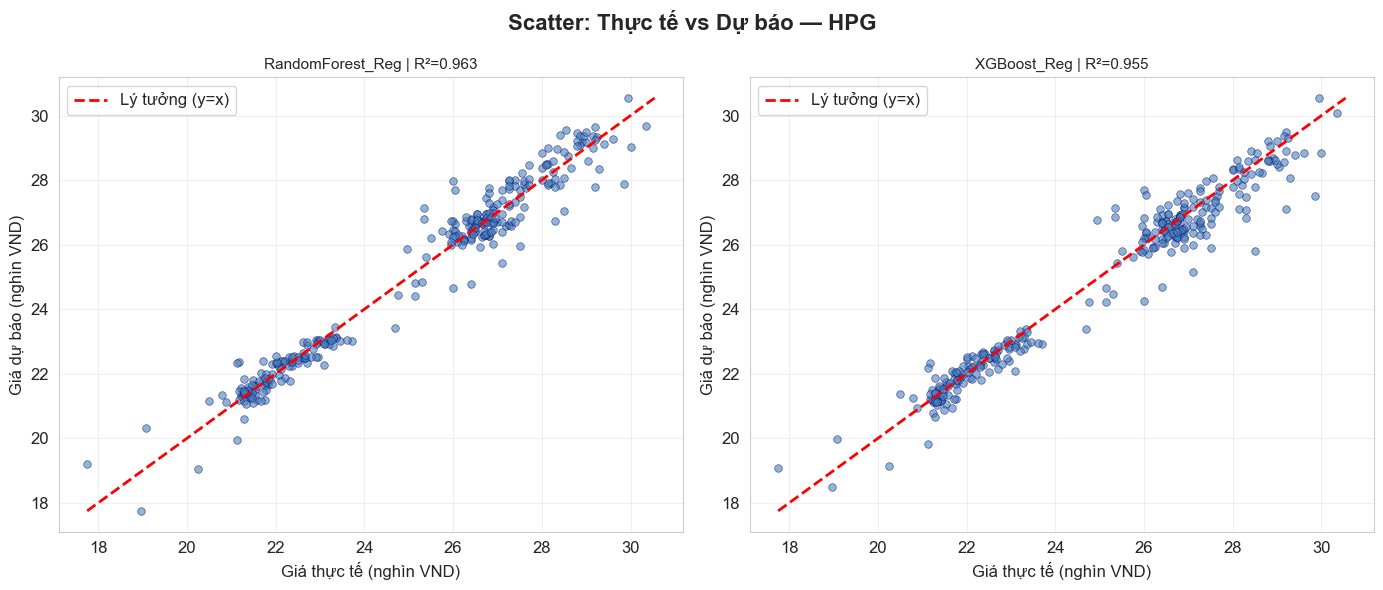

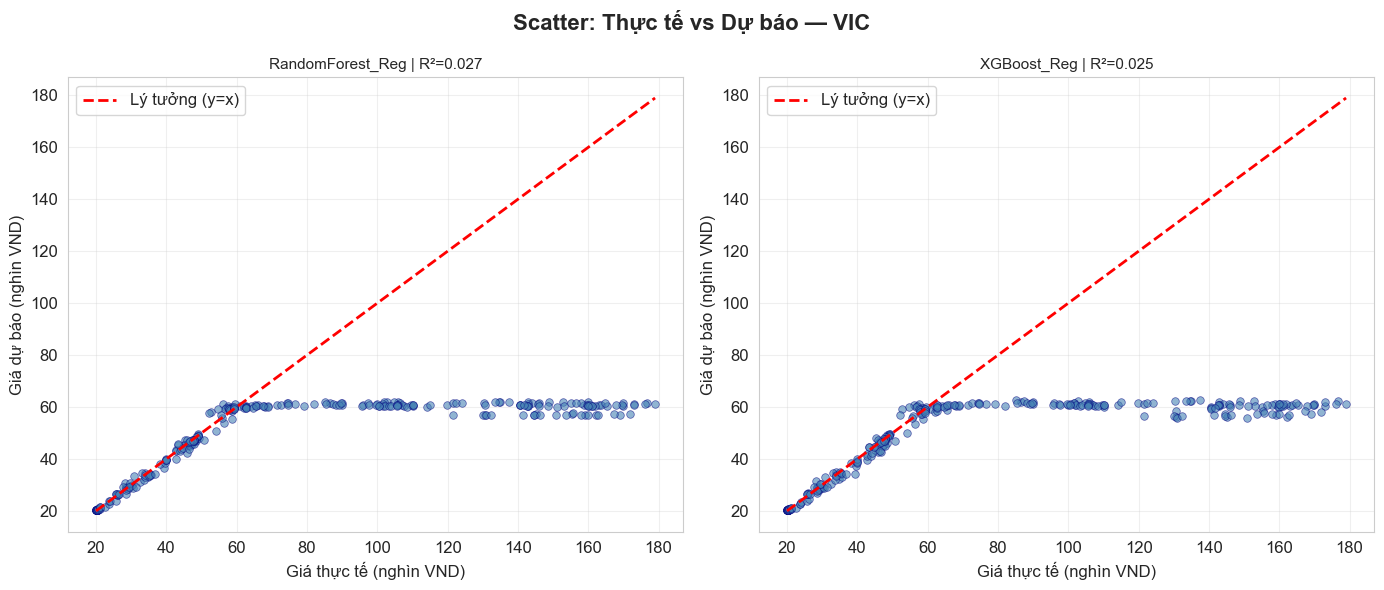

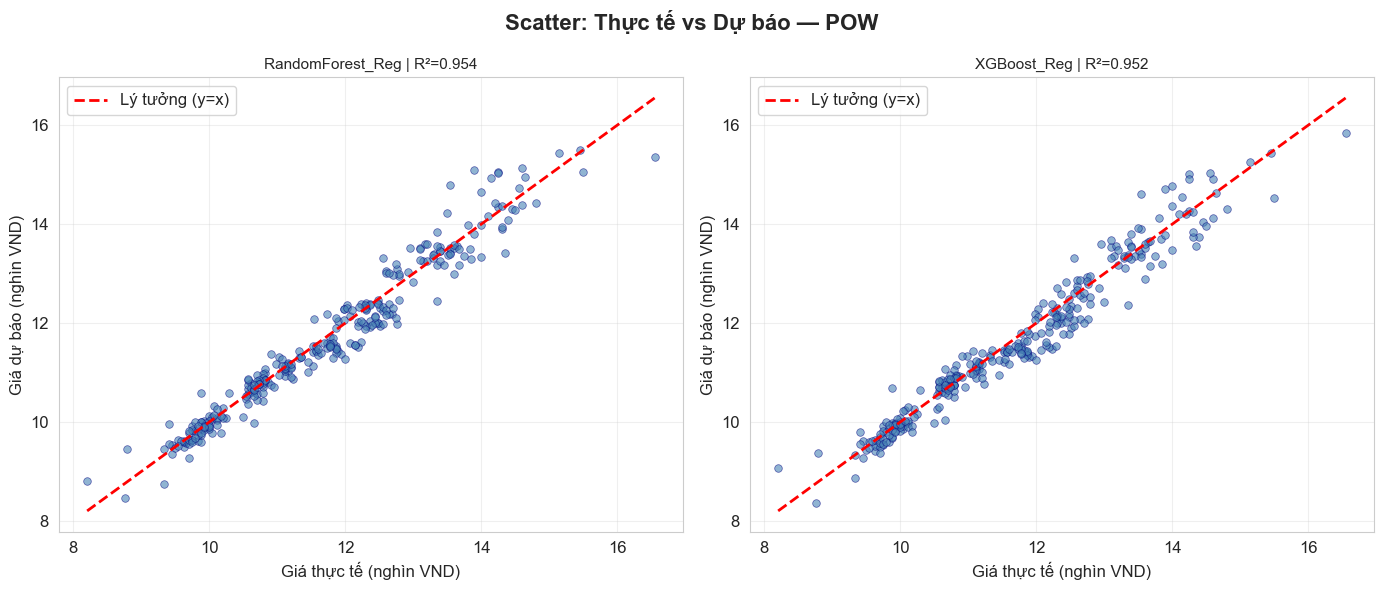

In [10]:
# === SCATTER PLOT: Giá thực tế vs Giá dự báo ===
for symbol in STOCK_SYMBOLS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Scatter: Thực tế vs Dự báo — {symbol}', fontsize=16, fontweight='bold')
    
    for idx, model_name in enumerate(REG_MODELS):
        ax = axes[idx]
        r = reg_eval[symbol][model_name]
        
        ax.scatter(r['y_true'], r['y_pred'], alpha=0.6, s=30, color='steelblue', edgecolors='navy', linewidth=0.5)
        
        # Đường lý tưởng (y_pred = y_true)
        min_val = min(r['y_true'].min(), r['y_pred'].min())
        max_val = max(r['y_true'].max(), r['y_pred'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Lý tưởng (y=x)')
        
        ax.set_title(f'{model_name} | R²={r["r2"]:.3f}', fontsize=11)
        ax.set_xlabel('Giá thực tế (nghìn VND)')
        ax.set_ylabel('Giá dự báo (nghìn VND)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, f'{symbol}_scatter_plot.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 5.6. Feature Importance — Đặc trưng quan trọng nhất

Feature Importance cho thấy **features nào đóng góp nhiều nhất** vào quyết định dự đoán của model.
- Tree-based models (Random Forest, XGBoost) có built-in feature importance
- Giúp hiểu model đang "nhìn vào đâu" khi đưa ra dự đoán
- Hữu ích cho việc feature selection và giải thích kết quả

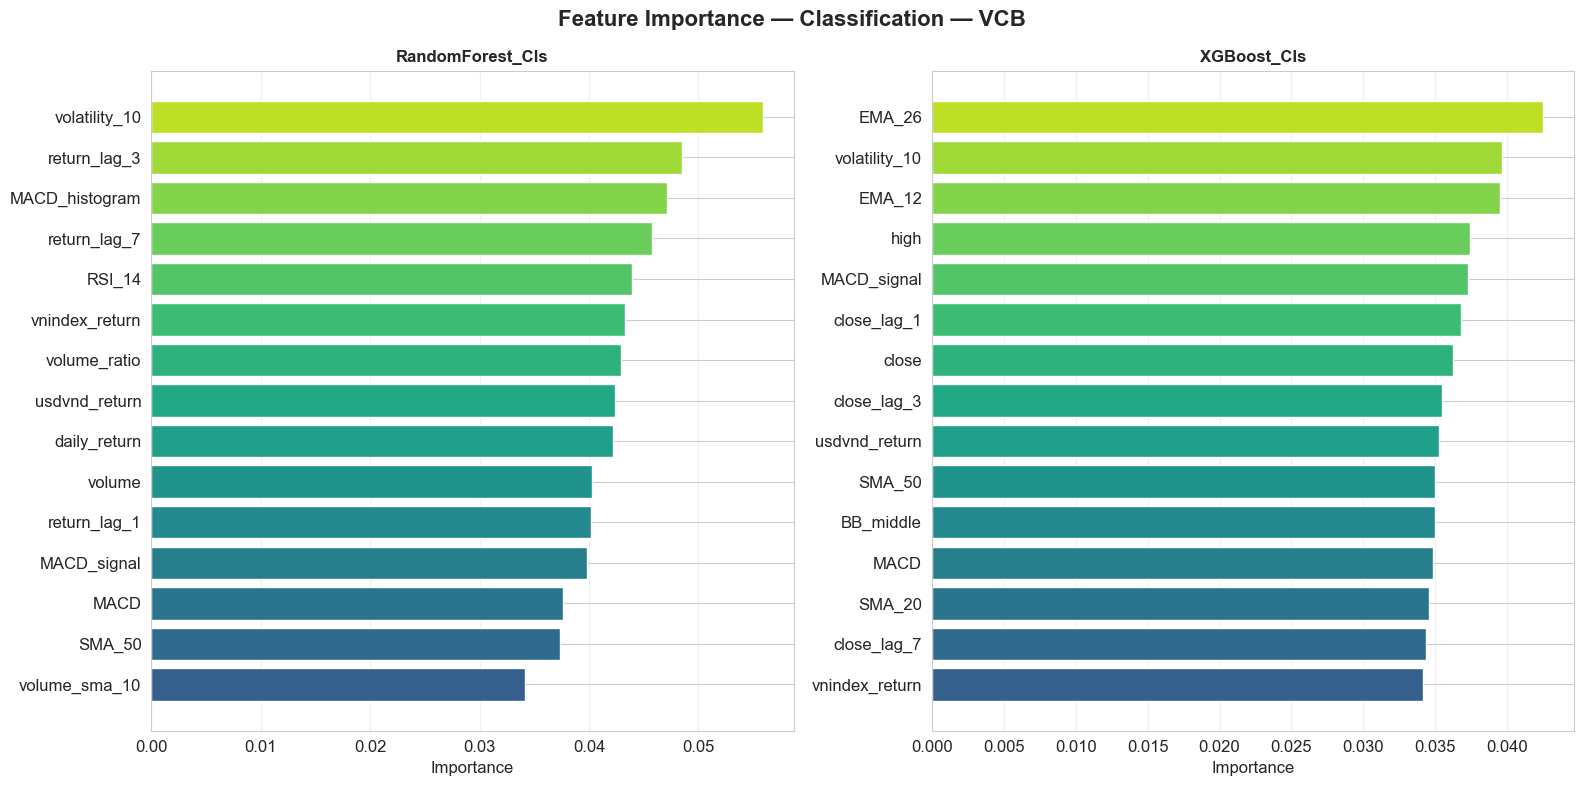

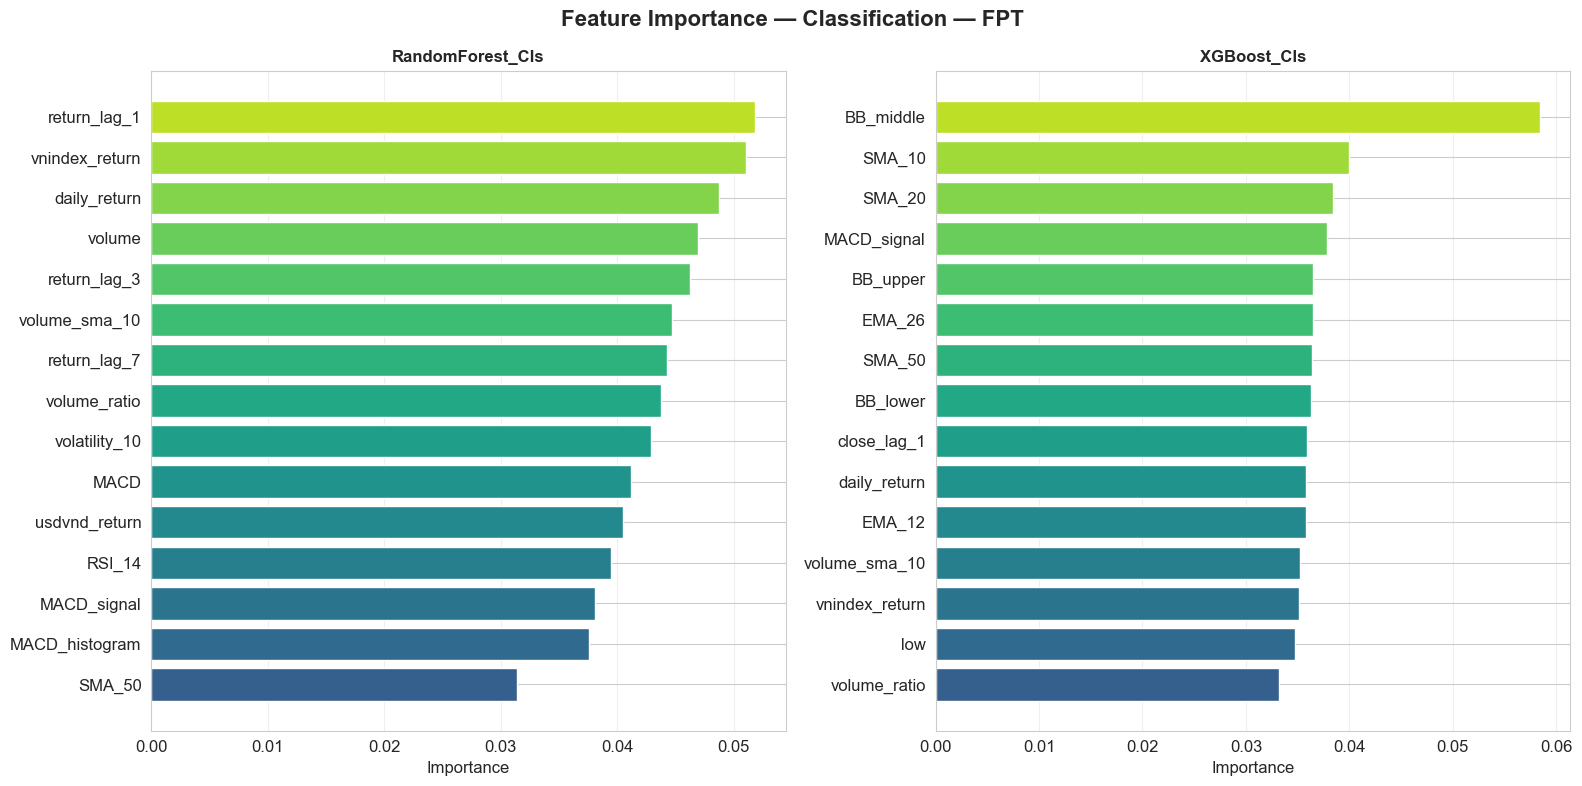

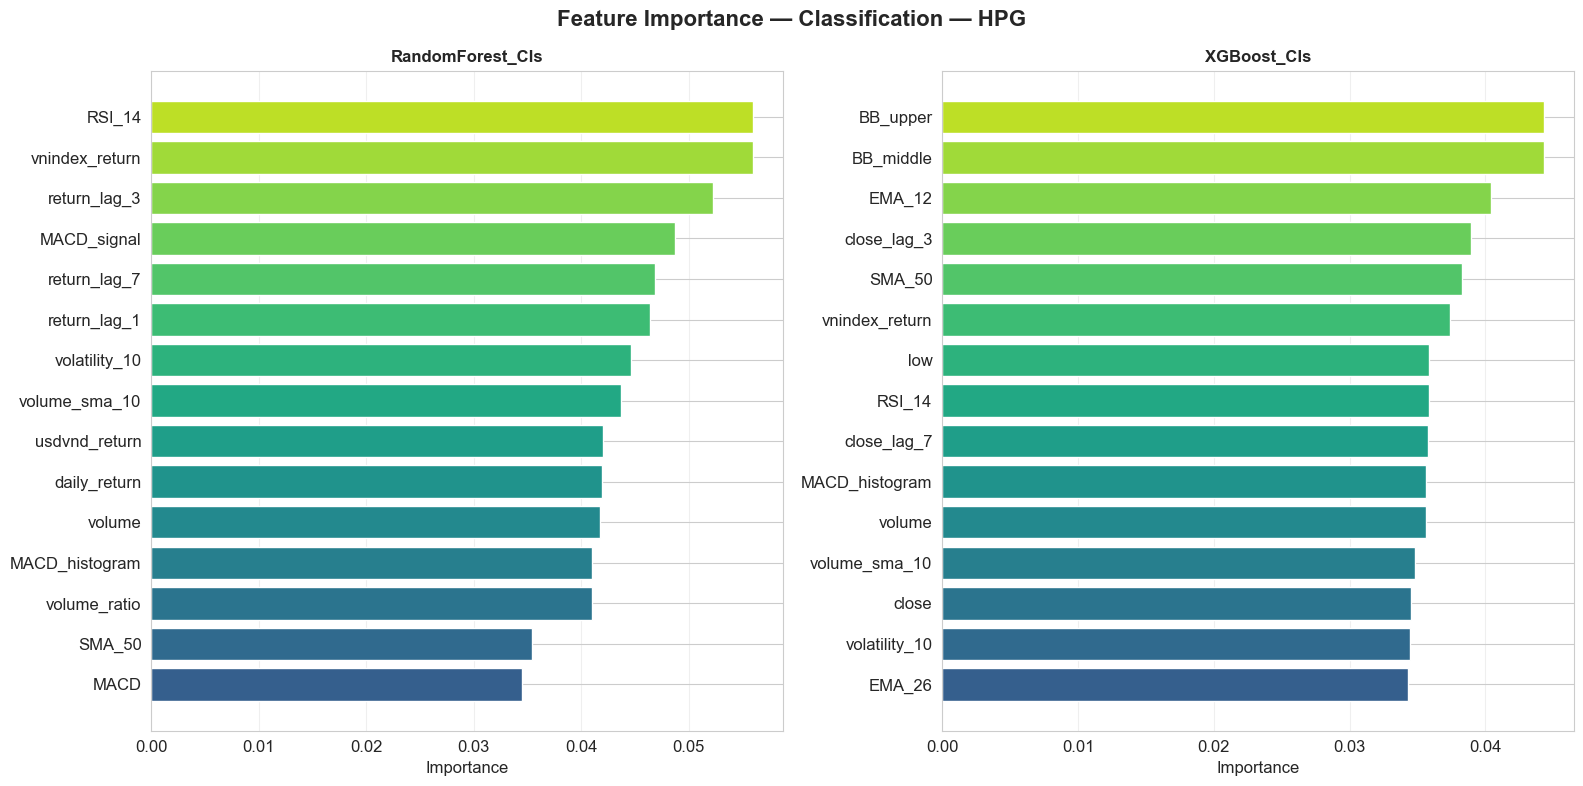

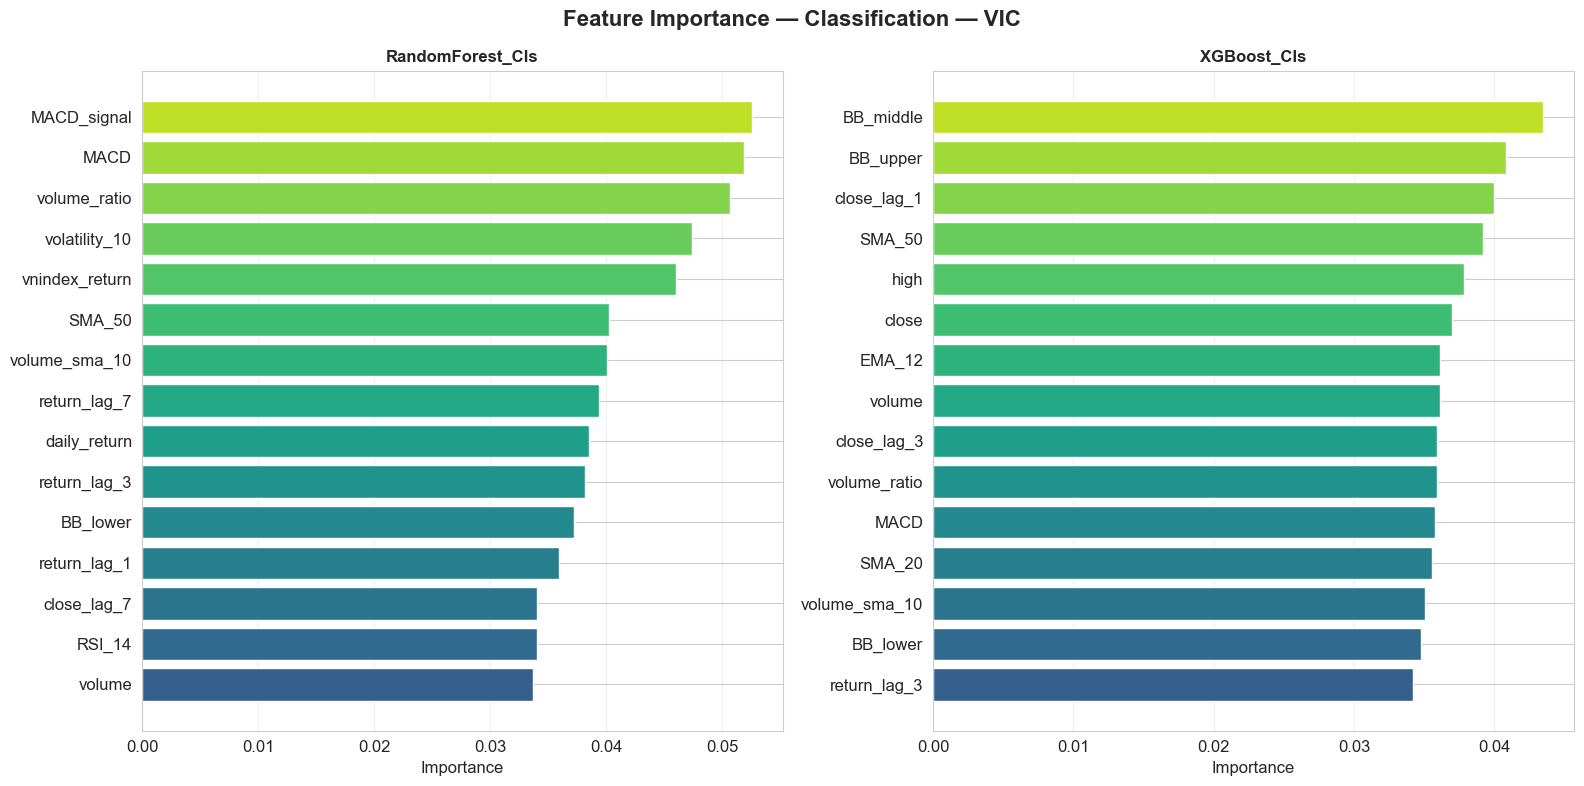

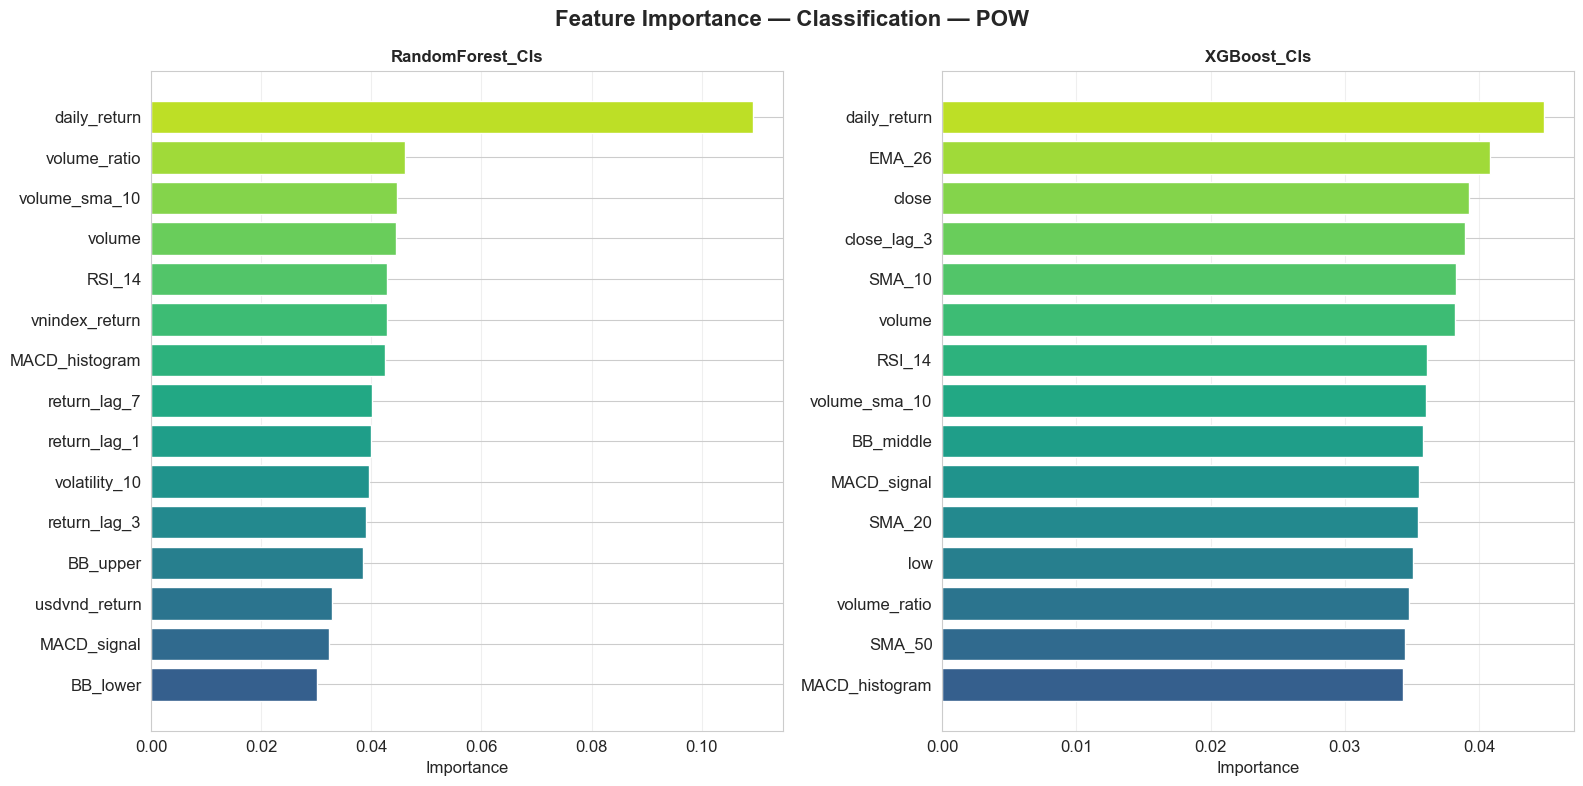

In [11]:
# === FEATURE IMPORTANCE — Classification (Top 15 features) ===
# Chỉ lấy tree-based models (RF, XGBoost) vì có feature_importances_
tree_clf_models = ['RandomForest_Cls', 'XGBoost_Cls']

for symbol in STOCK_SYMBOLS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f'Feature Importance — Classification — {symbol}', fontsize=16, fontweight='bold')
    
    for idx, model_name in enumerate(tree_clf_models):
        ax = axes[idx]
        model = models[symbol][model_name]
        
        importances = model.feature_importances_
        feat_imp = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': importances
        }).sort_values('Importance', ascending=True).tail(15)
        
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feat_imp)))
        ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)
        ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Importance')
        ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, f'{symbol}_feature_importance_cls.png'), dpi=150, bbox_inches='tight')
    plt.show()

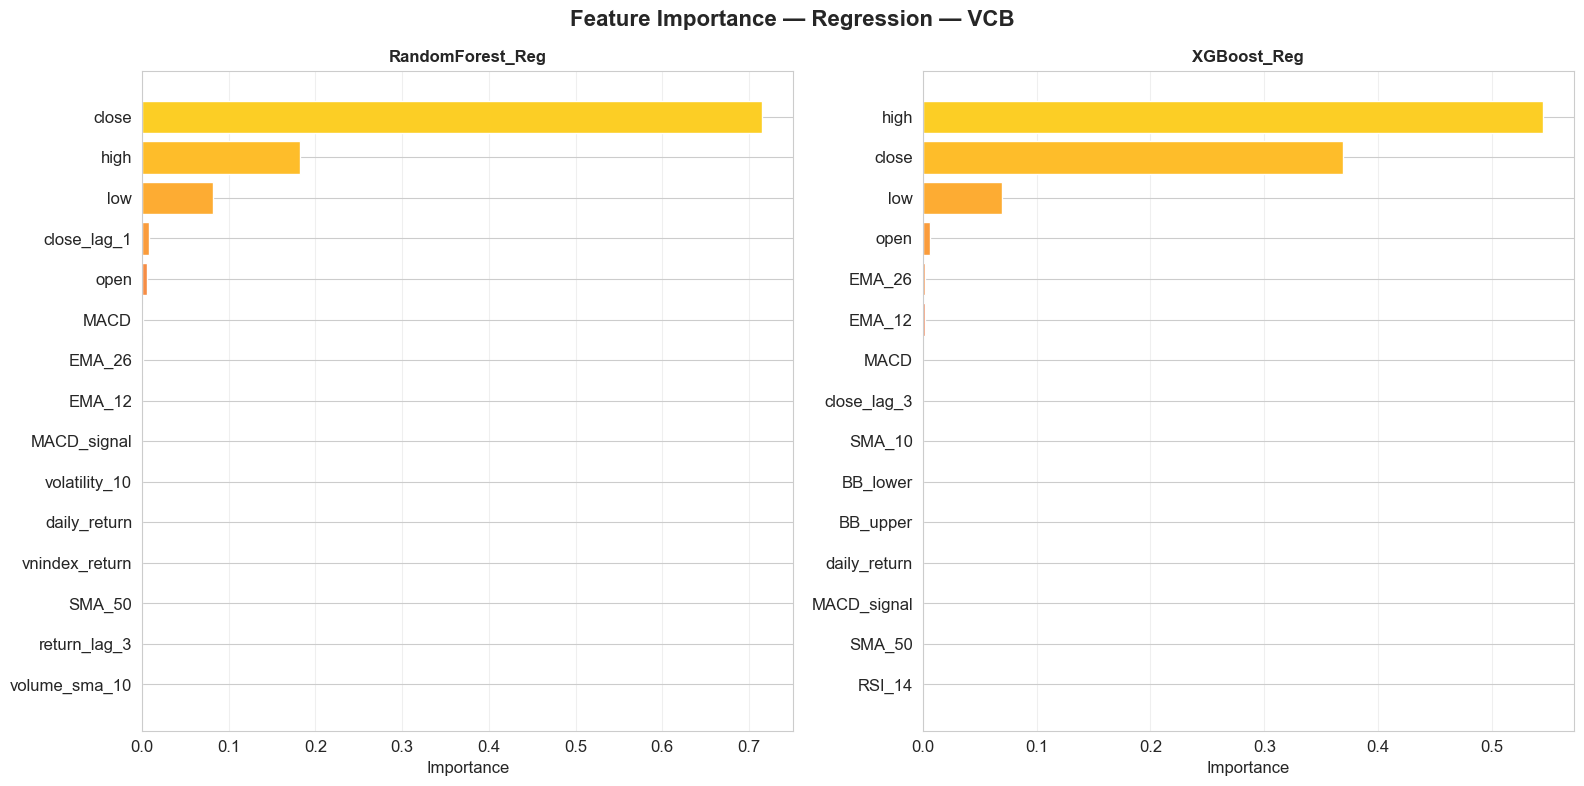

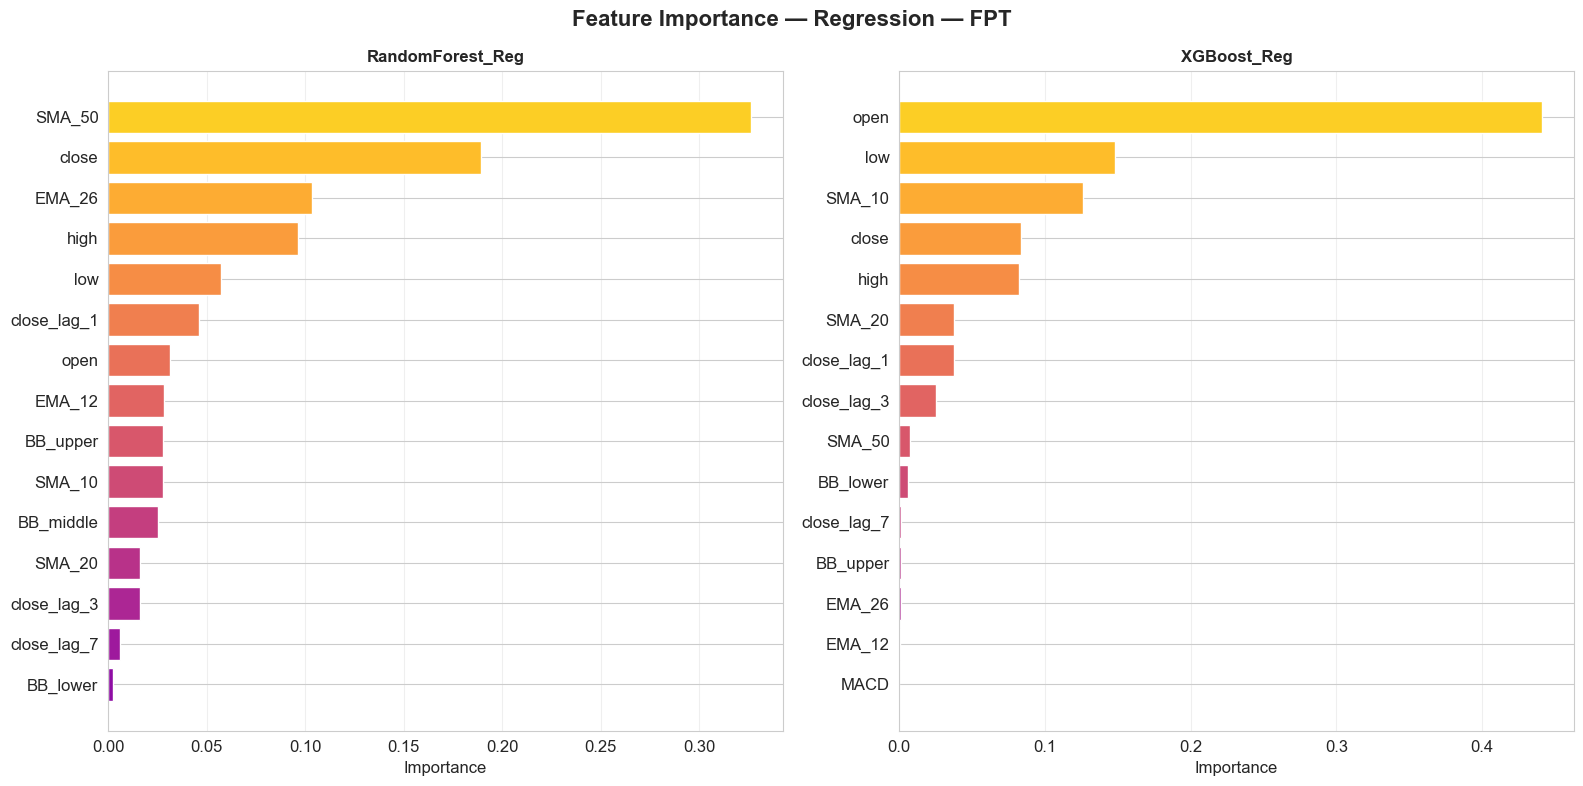

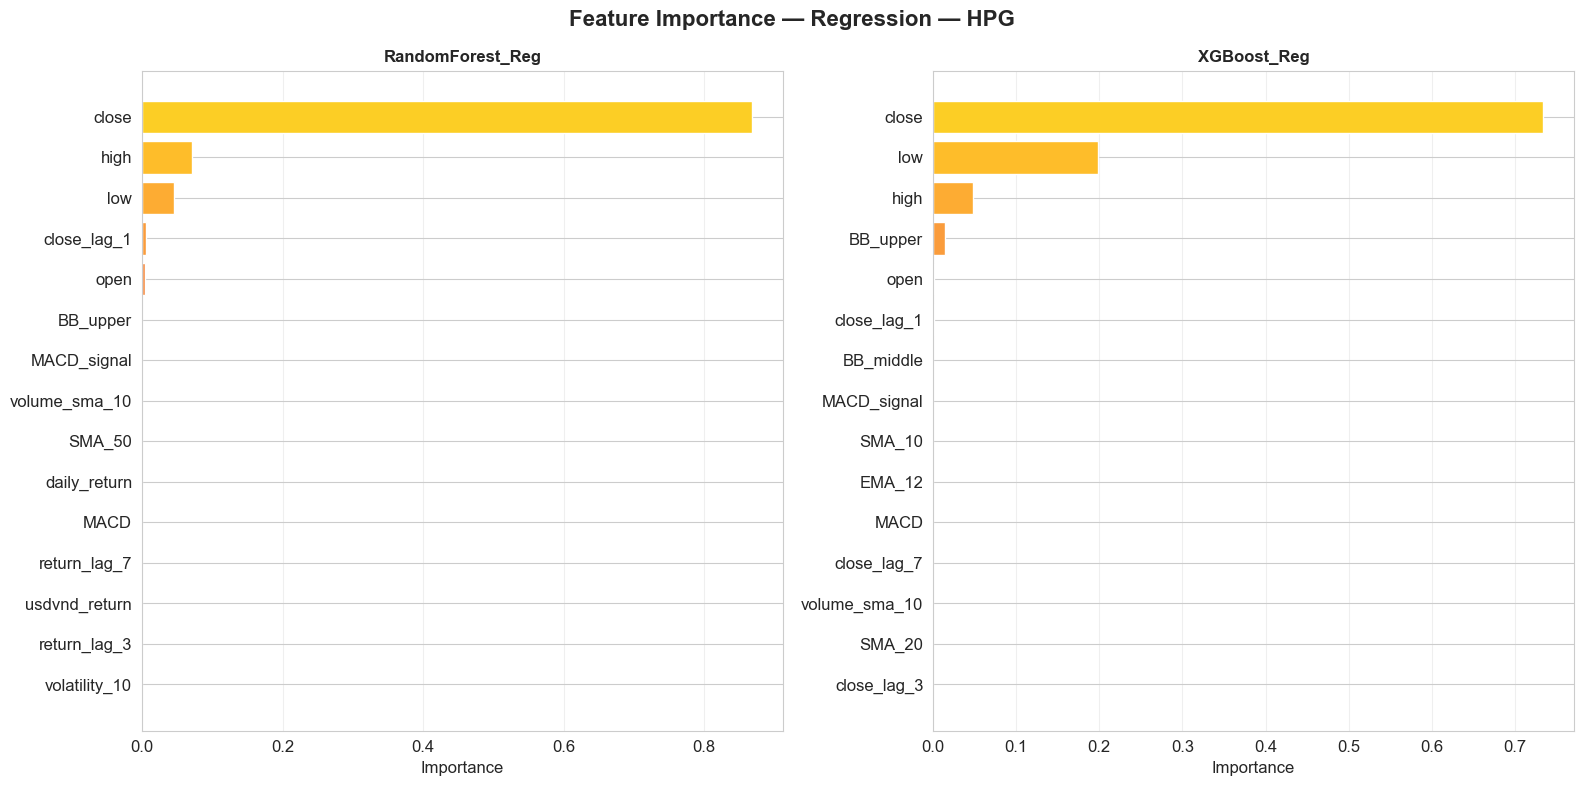

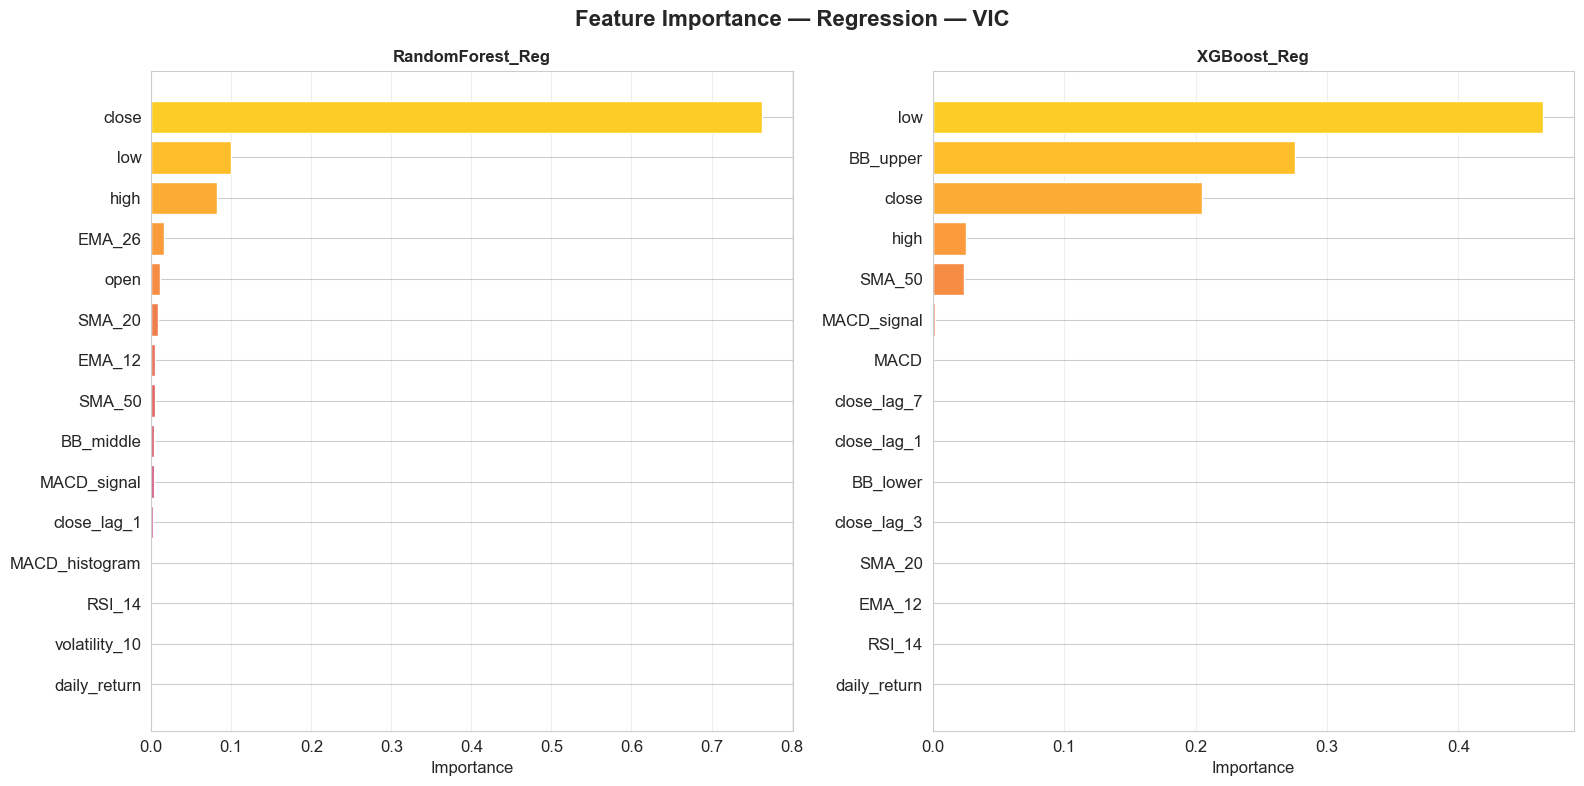

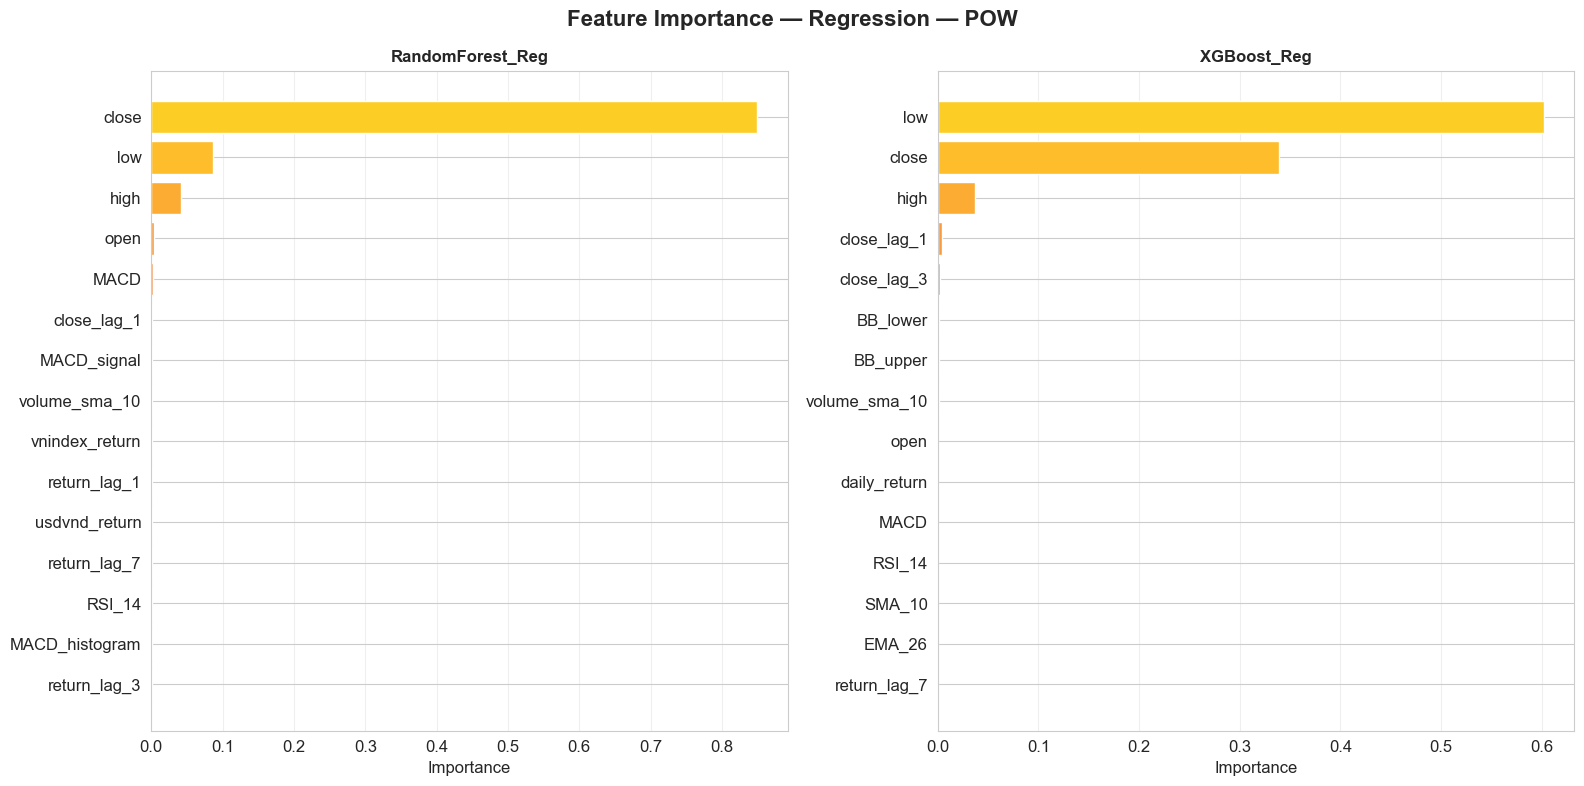


TOP 10 FEATURES QUAN TRỌNG NHẤT (Trung bình trên tất cả mã)

--- Classification (XGBoost) ---
  BB_middle                      0.0434
  EMA_26                         0.0374
  BB_upper                       0.0374
  EMA_12                         0.0372
  SMA_50                         0.0367
  close_lag_3                    0.0362
  SMA_10                         0.0361
  close                          0.0359
  MACD_signal                    0.0357
  volume                         0.0349

--- Regression (XGBoost) ---
  close                          0.3461
  low                            0.2966
  high                           0.1477
  open                           0.0899
  BB_upper                       0.0586
  SMA_10                         0.0255
  close_lag_1                    0.0086
  SMA_20                         0.0078
  SMA_50                         0.0063
  close_lag_3                    0.0057


In [12]:
# === FEATURE IMPORTANCE — Regression (Top 15 features) ===
for symbol in STOCK_SYMBOLS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f'Feature Importance — Regression — {symbol}', fontsize=16, fontweight='bold')
    
    for idx, model_name in enumerate(REG_MODELS):
        ax = axes[idx]
        model = models[symbol][model_name]
        
        importances = model.feature_importances_
        feat_imp = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': importances
        }).sort_values('Importance', ascending=True).tail(15)
        
        colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(feat_imp)))
        ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)
        ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Importance')
        ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, f'{symbol}_feature_importance_reg.png'), dpi=150, bbox_inches='tight')
    plt.show()

# === TỔNG HỢP FEATURE IMPORTANCE TRUNG BÌNH TRÊN TẤT CẢ CÁC MÃ ===
print("\n" + "=" * 70)
print("TOP 10 FEATURES QUAN TRỌNG NHẤT (Trung bình trên tất cả mã)")
print("=" * 70)

# Classification — XGBoost (thường là model tốt nhất)
all_imp_cls = np.zeros(len(feature_cols))
for symbol in STOCK_SYMBOLS:
    all_imp_cls += models[symbol]['XGBoost_Cls'].feature_importances_
all_imp_cls /= len(STOCK_SYMBOLS)

top10_cls = pd.DataFrame({'Feature': feature_cols, 'Avg Importance': all_imp_cls})\
    .sort_values('Avg Importance', ascending=False).head(10)
print("\n--- Classification (XGBoost) ---")
for i, row in top10_cls.iterrows():
    print(f"  {row['Feature']:30s} {row['Avg Importance']:.4f}")

# Regression — XGBoost
all_imp_reg = np.zeros(len(feature_cols))
for symbol in STOCK_SYMBOLS:
    all_imp_reg += models[symbol]['XGBoost_Reg'].feature_importances_
all_imp_reg /= len(STOCK_SYMBOLS)

top10_reg = pd.DataFrame({'Feature': feature_cols, 'Avg Importance': all_imp_reg})\
    .sort_values('Avg Importance', ascending=False).head(10)
print("\n--- Regression (XGBoost) ---")
for i, row in top10_reg.iterrows():
    print(f"  {row['Feature']:30s} {row['Avg Importance']:.4f}")

## 5.7. Learning Curve — Phân tích Overfitting/Underfitting

Learning Curve cho thấy hiệu suất model khi **tăng dần lượng dữ liệu training**:
- **Train score giảm + Validation score tăng** → model đang **học tốt**, thêm data sẽ cải thiện
- **Train score cao + Validation score thấp (gap lớn)** → **Overfitting** — model quá phức tạp
- **Cả hai đều thấp** → **Underfitting** — model quá đơn giản, cần feature mạnh hơn

> Sử dụng `TimeSeriesSplit(n_splits=5)` cho cross-validation trong learning curve.

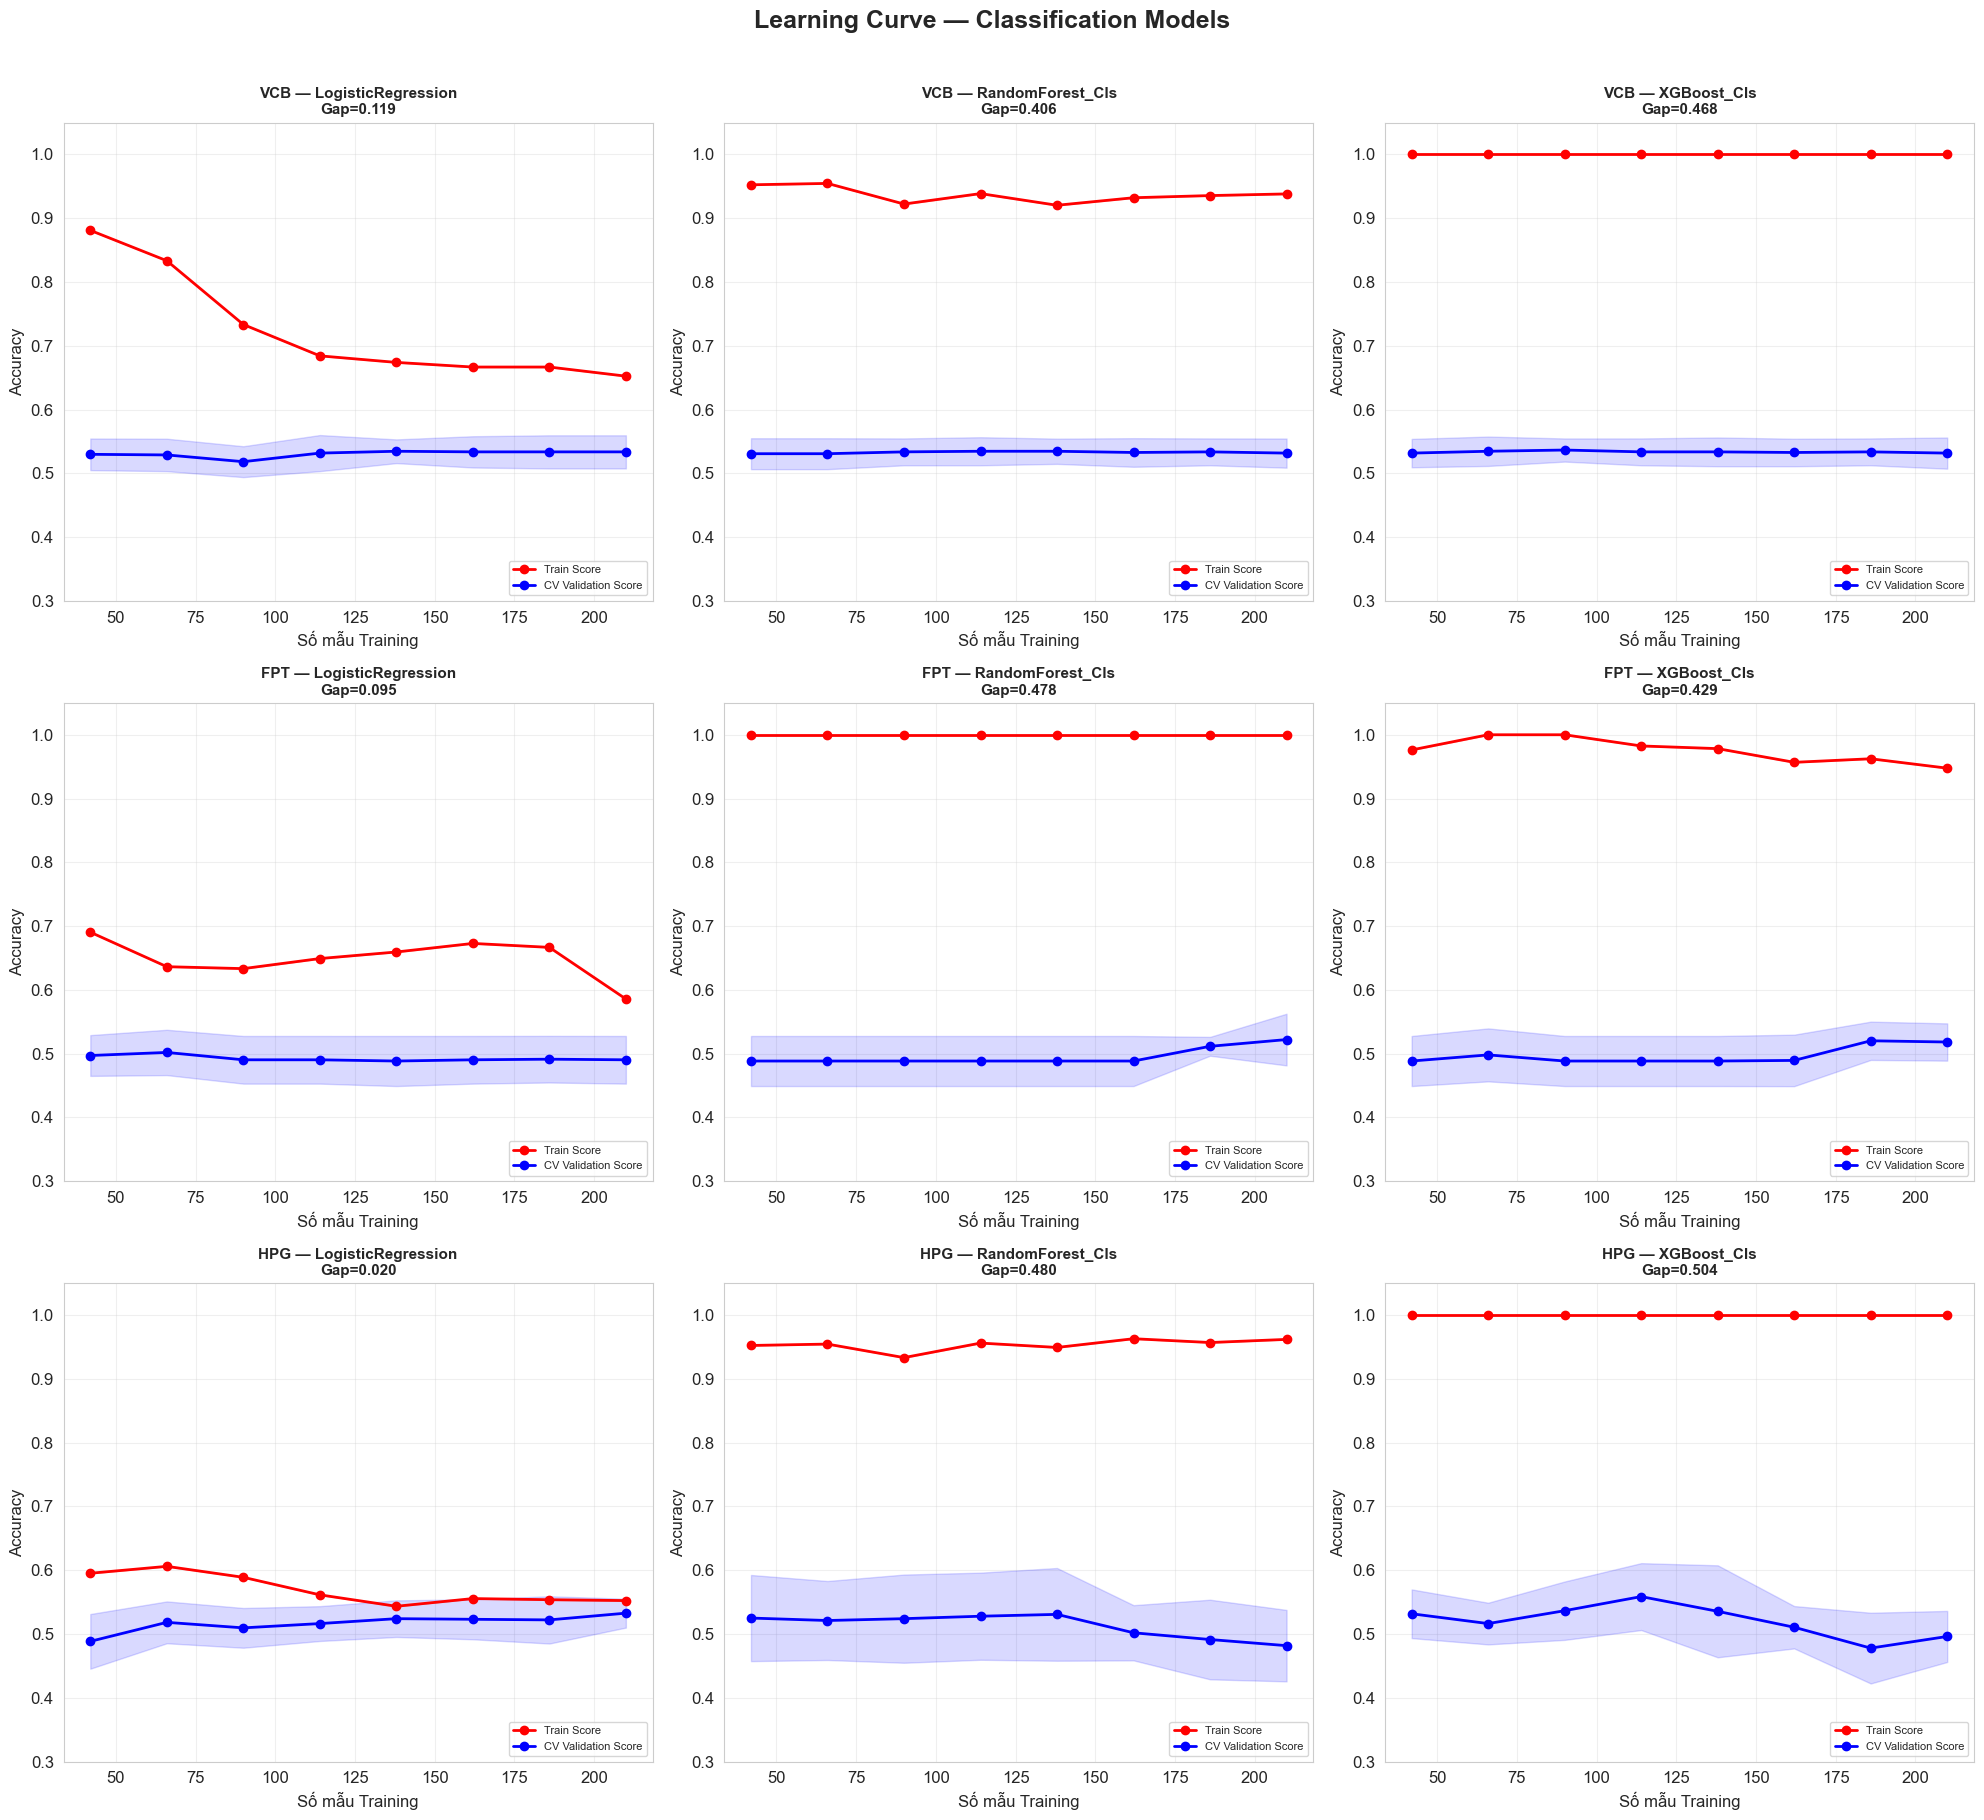

Nhận xét Learning Curve:
  - Gap nhỏ giữa Train/Validation → model generalize tốt
  - Gap lớn → overfitting, cần regularization hoặc giảm complexity
  - Cả 2 score đều thấp → underfitting, cần thêm features hoặc model phức tạp hơn


In [13]:
# === LEARNING CURVE — CLASSIFICATION ===
# Vẽ learning curve cho model tốt nhất (XGBoost) trên mỗi mã
from sklearn.model_selection import learning_curve

tscv = TimeSeriesSplit(n_splits=5)

# Chọn 2 mã đại diện để vẽ learning curve (tránh quá lâu)
sample_symbols = STOCK_SYMBOLS[:3]  # VCB, FPT, HPG

fig, axes = plt.subplots(len(sample_symbols), 3, figsize=(20, 6 * len(sample_symbols)))
fig.suptitle('Learning Curve — Classification Models', fontsize=18, fontweight='bold', y=1.01)

for row_idx, symbol in enumerate(sample_symbols):
    df_train = train_datasets[symbol]
    X_train = df_train[feature_cols].values
    y_train = df_train['target_cls'].values
    
    for col_idx, model_name in enumerate(CLF_MODELS):
        ax = axes[row_idx][col_idx]
        model = models[symbol][model_name]
        
        # Dùng scaled data cho Logistic Regression
        X = scalers[symbol].transform(X_train) if 'Logistic' in model_name else X_train
        
        # Tính learning curve
        train_sizes, train_scores, val_scores = learning_curve(
            model, X, y_train,
            cv=tscv,
            train_sizes=np.linspace(0.2, 1.0, 8),
            scoring='accuracy',
            n_jobs=-1,
            shuffle=False  # Quan trọng: KHÔNG shuffle cho time series
        )
        
        train_mean = train_scores.mean(axis=1)
        train_std = train_scores.std(axis=1)
        val_mean = val_scores.mean(axis=1)
        val_std = val_scores.std(axis=1)
        
        # Vẽ
        ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='red')
        ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
        ax.plot(train_sizes, train_mean, 'o-', color='red', linewidth=2, label='Train Score')
        ax.plot(train_sizes, val_mean, 'o-', color='blue', linewidth=2, label='CV Validation Score')
        
        gap = (train_mean[-1] - val_mean[-1])
        ax.set_title(f'{symbol} — {model_name}\nGap={gap:.3f}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Số mẫu Training')
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.3, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'learning_curve_classification.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Nhận xét Learning Curve:")
print("  - Gap nhỏ giữa Train/Validation → model generalize tốt")
print("  - Gap lớn → overfitting, cần regularization hoặc giảm complexity")
print("  - Cả 2 score đều thấp → underfitting, cần thêm features hoặc model phức tạp hơn")

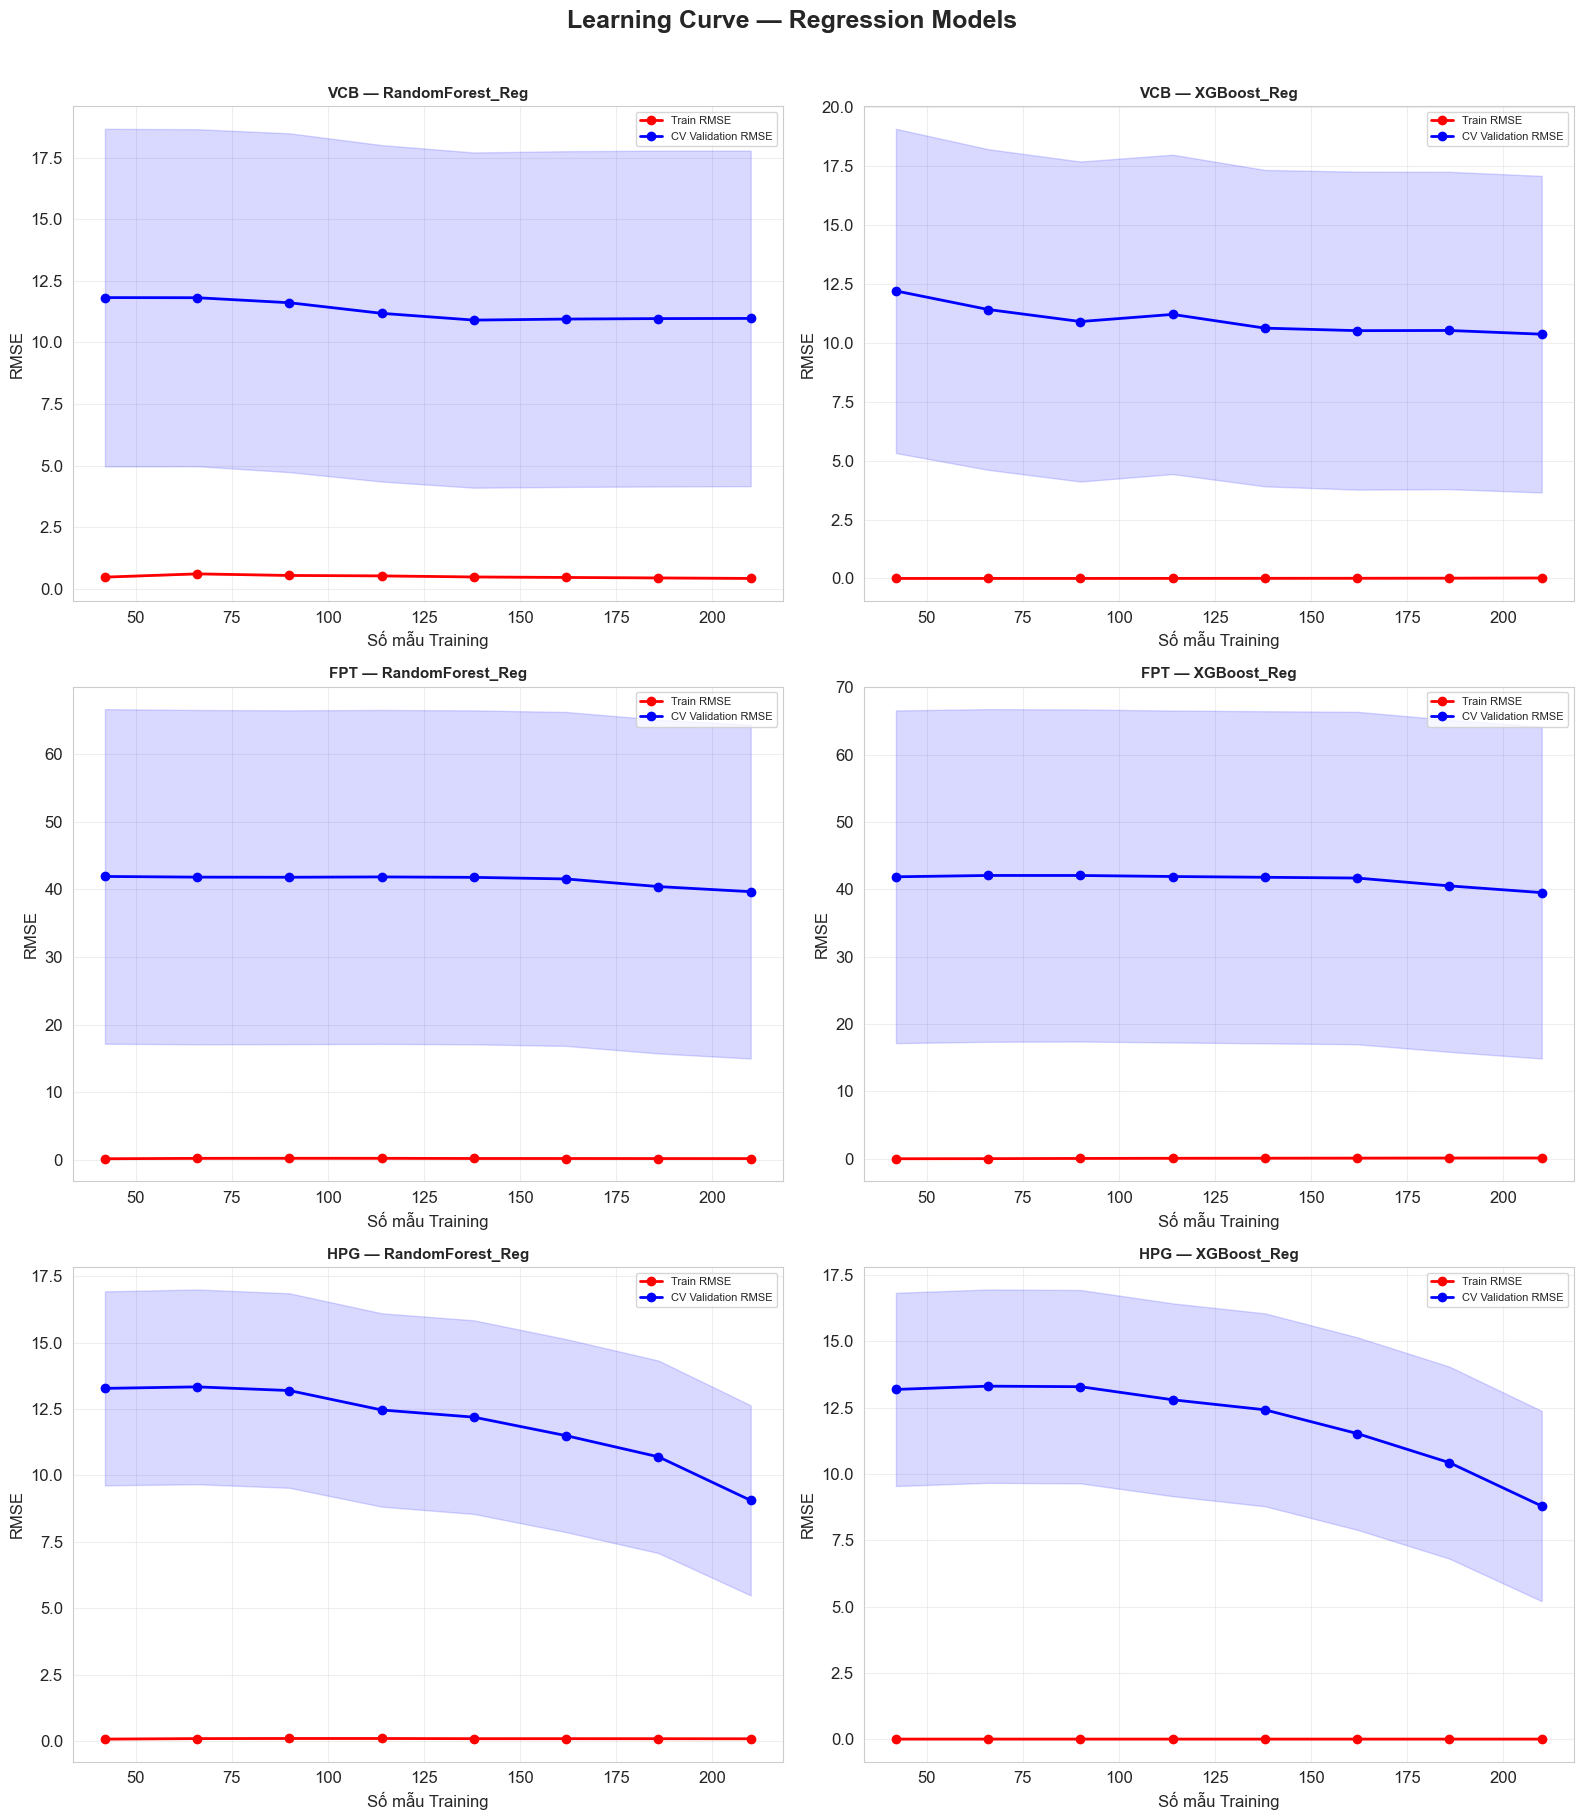

In [14]:
# === LEARNING CURVE — REGRESSION ===
fig, axes = plt.subplots(len(sample_symbols), 2, figsize=(16, 6 * len(sample_symbols)))
fig.suptitle('Learning Curve — Regression Models', fontsize=18, fontweight='bold', y=1.01)

for row_idx, symbol in enumerate(sample_symbols):
    df_train = train_datasets[symbol]
    X_train = df_train[feature_cols].values
    y_train = df_train['target_reg'].values
    
    for col_idx, model_name in enumerate(REG_MODELS):
        ax = axes[row_idx][col_idx]
        model = models[symbol][model_name]
        
        # Tính learning curve (scoring = neg_MSE)
        train_sizes, train_scores, val_scores = learning_curve(
            model, X_train, y_train,
            cv=tscv,
            train_sizes=np.linspace(0.2, 1.0, 8),
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            shuffle=False
        )
        
        # Đổi sang RMSE (dương)
        train_rmse = np.sqrt(-train_scores)
        val_rmse = np.sqrt(-val_scores)
        
        train_mean = train_rmse.mean(axis=1)
        train_std = train_rmse.std(axis=1)
        val_mean = val_rmse.mean(axis=1)
        val_std = val_rmse.std(axis=1)
        
        ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='red')
        ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
        ax.plot(train_sizes, train_mean, 'o-', color='red', linewidth=2, label='Train RMSE')
        ax.plot(train_sizes, val_mean, 'o-', color='blue', linewidth=2, label='CV Validation RMSE')
        
        ax.set_title(f'{symbol} — {model_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Số mẫu Training')
        ax.set_ylabel('RMSE')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'learning_curve_regression.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5.8. Tổng hợp & Nhận xét — Chọn mô hình tốt nhất

### Tiêu chí lựa chọn:
1. **Hiệu suất trên tập test** (F1/Accuracy cho phân loại, RMSE/R² cho hồi quy)
2. **Khả năng generalization** (chênh lệch CV vs Test nhỏ)
3. **Tính ổn định** qua các mã cổ phiếu khác nhau
4. **Khả năng diễn giải** (Feature Importance rõ ràng)

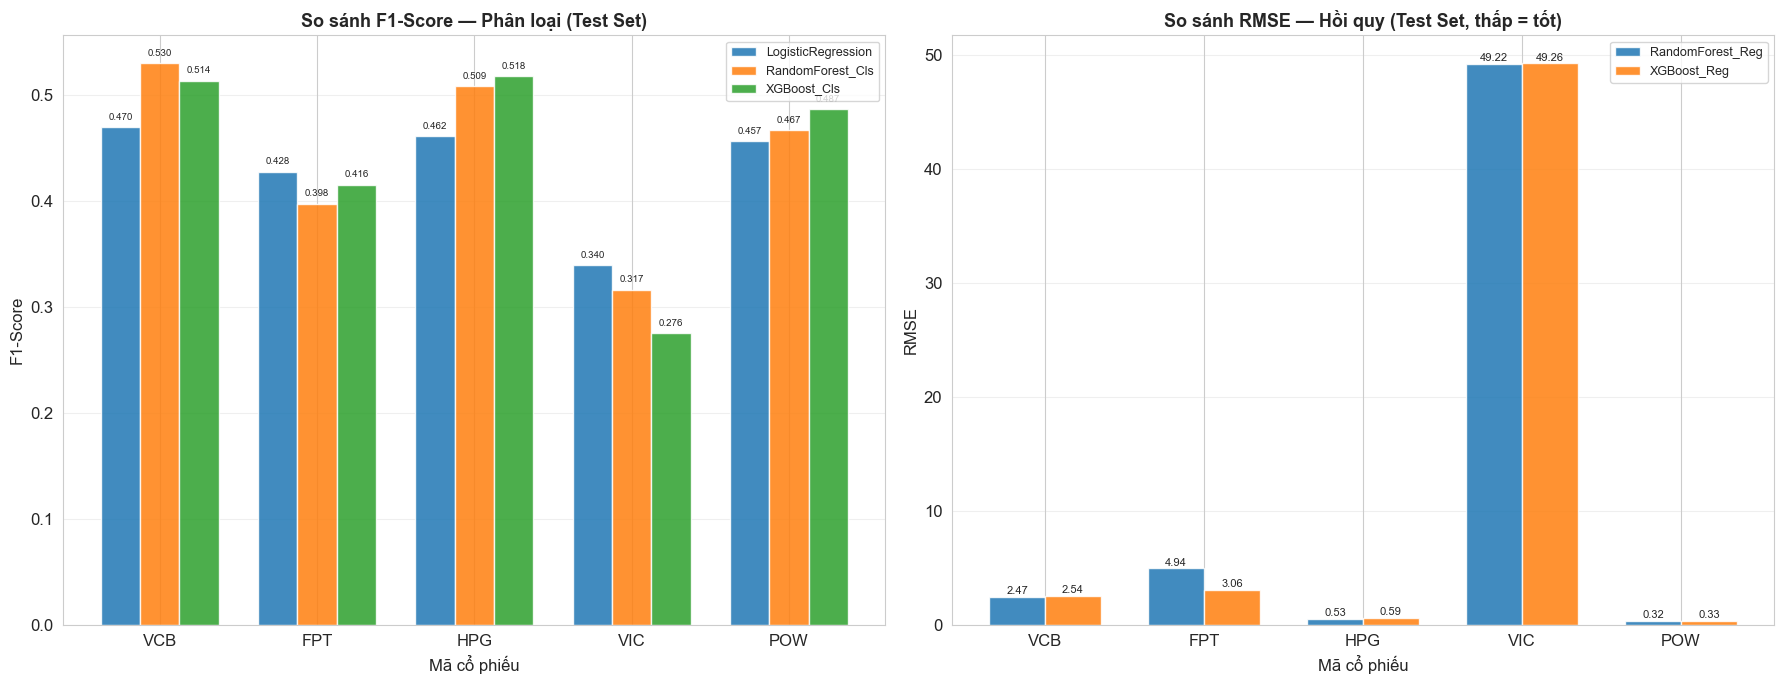

In [15]:
# === BIỂU ĐỒ TỔNG HỢP SO SÁNH TẤT CẢ MÔ HÌNH ===

# 1. Bar chart so sánh Accuracy tất cả models
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Classification: F1-Score ---
ax = axes[0]
x = np.arange(len(STOCK_SYMBOLS))
width = 0.25

for i, model_name in enumerate(CLF_MODELS):
    f1_scores = [clf_eval[s][model_name]['f1'] for s in STOCK_SYMBOLS]
    bars = ax.bar(x + i * width, f1_scores, width, label=model_name, alpha=0.85)
    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{score:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Mã cổ phiếu')
ax.set_ylabel('F1-Score')
ax.set_title('So sánh F1-Score — Phân loại (Test Set)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(STOCK_SYMBOLS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Regression: RMSE ---
ax = axes[1]
width = 0.35

for i, model_name in enumerate(REG_MODELS):
    rmse_scores = [reg_eval[s][model_name]['rmse'] for s in STOCK_SYMBOLS]
    bars = ax.bar(x + i * width, rmse_scores, width, label=model_name, alpha=0.85)
    for bar, score in zip(bars, rmse_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                f'{score:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Mã cổ phiếu')
ax.set_ylabel('RMSE')
ax.set_title('So sánh RMSE — Hồi quy (Test Set, thấp = tốt)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(STOCK_SYMBOLS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'model_comparison_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# === CHỌN MÔ HÌNH TỐT NHẤT CHO TỪNG MÃ ===
print("=" * 100)
print("KẾT LUẬN — MÔ HÌNH TỐT NHẤT CHO TỪNG MÃ CỔ PHIẾU")
print("=" * 100)

best_models_summary = []

print("\n--- BÀI TOÁN PHÂN LOẠI (Tiêu chí: F1-Score cao nhất trên Test Set) ---\n")
print(f"{'Mã CP':8s} {'Best Model':25s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s} {'F1-Score':>10s}")
print("-" * 80)

for symbol in STOCK_SYMBOLS:
    best_name = max(CLF_MODELS, key=lambda m: clf_eval[symbol][m]['f1'])
    r = clf_eval[symbol][best_name]
    print(f"{symbol:8s} {best_name:25s} {r['accuracy']:10.4f} {r['precision']:10.4f} {r['recall']:10.4f} {r['f1']:10.4f}")
    best_models_summary.append({
        'symbol': symbol, 'task': 'Classification', 
        'best_model': best_name, 'score': r['f1'], 'metric': 'F1'
    })

print(f"\n--- BÀI TOÁN HỒI QUY (Tiêu chí: RMSE thấp nhất trên Test Set) ---\n")
print(f"{'Mã CP':8s} {'Best Model':25s} {'MSE':>12s} {'MAE':>10s} {'RMSE':>10s} {'R²':>10s} {'MAPE%':>10s}")
print("-" * 90)

for symbol in STOCK_SYMBOLS:
    best_name = min(REG_MODELS, key=lambda m: reg_eval[symbol][m]['rmse'])
    r = reg_eval[symbol][best_name]
    print(f"{symbol:8s} {best_name:25s} {r['mse']:12.4f} {r['mae']:10.4f} {r['rmse']:10.4f} {r['r2']:10.4f} {r['mape']:10.2f}")
    best_models_summary.append({
        'symbol': symbol, 'task': 'Regression',
        'best_model': best_name, 'score': r['rmse'], 'metric': 'RMSE'
    })

KẾT LUẬN — MÔ HÌNH TỐT NHẤT CHO TỪNG MÃ CỔ PHIẾU

--- BÀI TOÁN PHÂN LOẠI (Tiêu chí: F1-Score cao nhất trên Test Set) ---

Mã CP    Best Model                  Accuracy  Precision     Recall   F1-Score
--------------------------------------------------------------------------------
VCB      RandomForest_Cls              0.5541     0.5332     0.5541     0.5302
FPT      LogisticRegression            0.5034     0.6296     0.5034     0.4279
HPG      XGBoost_Cls                   0.5304     0.5205     0.5304     0.5180
VIC      LogisticRegression            0.4662     0.5718     0.4662     0.3397
POW      XGBoost_Cls                   0.5372     0.5138     0.5372     0.4871

--- BÀI TOÁN HỒI QUY (Tiêu chí: RMSE thấp nhất trên Test Set) ---

Mã CP    Best Model                         MSE        MAE       RMSE         R²      MAPE%
------------------------------------------------------------------------------------------
VCB      RandomForest_Reg                6.1117     1.3224     2.4722   

In [17]:
# === PHÂN TÍCH TỔNG HỢP & NHẬN XÉT CHUYÊN SÂU ===
print("=" * 100)
print("PHÂN TÍCH TỔNG HỢP & NHẬN XÉT")
print("=" * 100)

# Tính trung bình qua tất cả mã
print("\n--- TRUNG BÌNH METRICS QUA TẤT CẢ 5 MÃ ---\n")

# Classification
print("PHÂN LOẠI:")
print(f"{'Model':25s} {'Avg Acc':>10s} {'Avg F1':>10s} {'Avg Prec':>10s} {'Avg Recall':>12s}")
print("-" * 70)
for model_name in CLF_MODELS:
    avg_acc = np.mean([clf_eval[s][model_name]['accuracy'] for s in STOCK_SYMBOLS])
    avg_f1 = np.mean([clf_eval[s][model_name]['f1'] for s in STOCK_SYMBOLS])
    avg_prec = np.mean([clf_eval[s][model_name]['precision'] for s in STOCK_SYMBOLS])
    avg_rec = np.mean([clf_eval[s][model_name]['recall'] for s in STOCK_SYMBOLS])
    print(f"{model_name:25s} {avg_acc:10.4f} {avg_f1:10.4f} {avg_prec:10.4f} {avg_rec:12.4f}")

# Regression
print(f"\nHỒI QUY:")
print(f"{'Model':25s} {'Avg RMSE':>10s} {'Avg MAE':>10s} {'Avg R²':>10s} {'Avg MAPE%':>12s}")
print("-" * 70)
for model_name in REG_MODELS:
    avg_rmse = np.mean([reg_eval[s][model_name]['rmse'] for s in STOCK_SYMBOLS])
    avg_mae = np.mean([reg_eval[s][model_name]['mae'] for s in STOCK_SYMBOLS])
    avg_r2 = np.mean([reg_eval[s][model_name]['r2'] for s in STOCK_SYMBOLS])
    avg_mape = np.mean([reg_eval[s][model_name]['mape'] for s in STOCK_SYMBOLS])
    print(f"{model_name:25s} {avg_rmse:10.4f} {avg_mae:10.4f} {avg_r2:10.4f} {avg_mape:12.2f}")

# Đếm số lần mỗi model thắng
print(f"\n--- SỐ LẦN THẮNG TRÊN 5 MÃ ---\n")
from collections import Counter

cls_wins = Counter()
reg_wins = Counter()
for symbol in STOCK_SYMBOLS:
    best_cls = max(CLF_MODELS, key=lambda m: clf_eval[symbol][m]['f1'])
    best_reg = min(REG_MODELS, key=lambda m: reg_eval[symbol][m]['rmse'])
    cls_wins[best_cls] += 1
    reg_wins[best_reg] += 1

print("Phân loại (F1 cao nhất):")
for model, count in cls_wins.most_common():
    print(f"  {model}: {count}/5 mã")

print(f"\nHồi quy (RMSE thấp nhất):")
for model, count in reg_wins.most_common():
    print(f"  {model}: {count}/5 mã")

PHÂN TÍCH TỔNG HỢP & NHẬN XÉT

--- TRUNG BÌNH METRICS QUA TẤT CẢ 5 MÃ ---

PHÂN LOẠI:
Model                        Avg Acc     Avg F1   Avg Prec   Avg Recall
----------------------------------------------------------------------
LogisticRegression            0.5304     0.4313     0.5675       0.5304
RandomForest_Cls              0.5162     0.4441     0.5516       0.5162
XGBoost_Cls                   0.5027     0.4421     0.4537       0.5027

HỒI QUY:
Model                       Avg RMSE    Avg MAE     Avg R²    Avg MAPE%
----------------------------------------------------------------------
RandomForest_Reg             11.4966     7.1216     0.6743         6.42
XGBoost_Reg                  11.1537     6.8775     0.6941         6.23

--- SỐ LẦN THẮNG TRÊN 5 MÃ ---

Phân loại (F1 cao nhất):
  LogisticRegression: 2/5 mã
  XGBoost_Cls: 2/5 mã
  RandomForest_Cls: 1/5 mã

Hồi quy (RMSE thấp nhất):
  RandomForest_Reg: 4/5 mã
  XGBoost_Reg: 1/5 mã


In [18]:
# === LƯU KẾT QUẢ ĐÁNH GIÁ ===
# Lưu evaluation results để dùng cho Bước 6 (Inference)
eval_results = {
    'clf_eval': {
        s: {m: {k: v for k, v in clf_eval[s][m].items() if k not in ['y_true', 'y_pred']}
            for m in CLF_MODELS}
        for s in STOCK_SYMBOLS
    },
    'reg_eval': {
        s: {m: {k: v for k, v in reg_eval[s][m].items() if k not in ['y_true', 'y_pred', 'dates']}
            for m in REG_MODELS}
        for s in STOCK_SYMBOLS
    },
    'best_cls_models': {s: max(CLF_MODELS, key=lambda m: clf_eval[s][m]['f1']) for s in STOCK_SYMBOLS},
    'best_reg_models': {s: min(REG_MODELS, key=lambda m: reg_eval[s][m]['rmse']) for s in STOCK_SYMBOLS},
}

eval_path = os.path.join(MODELS_DIR, 'evaluation_results.pkl')
with open(eval_path, 'wb') as f:
    pickle.dump(eval_results, f)

# Lưu bảng metrics ra CSV
clf_summary_df.to_csv(os.path.join(OUTPUTS_DIR, 'classification_metrics.csv'), index=False)
reg_summary_df.to_csv(os.path.join(OUTPUTS_DIR, 'regression_metrics.csv'), index=False)

print(f"✓ Evaluation results → {eval_path}")
print(f"✓ Classification metrics → outputs/classification_metrics.csv")
print(f"✓ Regression metrics → outputs/regression_metrics.csv")
print(f"\nBiểu đồ đã lưu trong thư mục outputs/:")
for f_name in sorted(os.listdir(OUTPUTS_DIR)):
    if f_name.endswith('.png') or f_name.endswith('.csv'):
        size_kb = os.path.getsize(os.path.join(OUTPUTS_DIR, f_name)) / 1024
        print(f"  {f_name} ({size_kb:.1f} KB)")

✓ Evaluation results → ..\models\evaluation_results.pkl
✓ Classification metrics → outputs/classification_metrics.csv
✓ Regression metrics → outputs/regression_metrics.csv

Biểu đồ đã lưu trong thư mục outputs/:
  FPT_confusion_matrix.png (81.8 KB)
  FPT_feature_importance_cls.png (106.2 KB)
  FPT_feature_importance_reg.png (96.1 KB)
  FPT_price_prediction.png (236.5 KB)
  FPT_scatter_plot.png (168.6 KB)
  HPG_confusion_matrix.png (82.2 KB)
  HPG_feature_importance_cls.png (103.6 KB)
  HPG_feature_importance_reg.png (93.2 KB)
  HPG_price_prediction.png (239.9 KB)
  HPG_scatter_plot.png (165.4 KB)
  POW_confusion_matrix.png (79.2 KB)
  POW_feature_importance_cls.png (105.4 KB)
  POW_feature_importance_reg.png (95.4 KB)
  POW_price_prediction.png (228.3 KB)
  POW_scatter_plot.png (162.8 KB)
  VCB_confusion_matrix.png (81.5 KB)
  VCB_feature_importance_cls.png (105.7 KB)
  VCB_feature_importance_reg.png (96.6 KB)
  VCB_price_prediction.png (232.4 KB)
  VCB_scatter_plot.png (150.9 KB)
  VI

## Tổng kết Bước 5 — Huấn Luyện & Đánh Giá

### Phương pháp đánh giá:
- **TimeSeriesSplit(n_splits=5)** cho cross-validation — KHÔNG dùng random split
- Train: 2020–2024 | Test: 2025–hiện tại (dữ liệu model chưa thấy)
- Đánh giá trên **tất cả 5 mã cổ phiếu** × **5 models** = 25 cặp đánh giá

### Metrics đầy đủ:
- **Phân loại**: Accuracy, Precision, Recall, F1-Score + Confusion Matrix
- **Hồi quy**: MSE, MAE, RMSE, R², MAPE + Biểu đồ giá dự báo vs thực tế

### Trực quan hóa:
- **Confusion Matrix** cho từng model × từng mã
- **Biểu đồ giá dự báo vs thực tế** (line chart + scatter plot)
- **Feature Importance** — Top 15 features quan trọng nhất
- **Learning Curve** — Phân tích overfitting/underfitting

### Kết quả:
- Bảng so sánh tổng hợp tất cả models
- Chọn model tốt nhất cho từng mã có lý giải
- Phân tích overfitting qua CV vs Test gap

### Bước tiếp theo:
→ **Bước 6: Suy Luận & Cập Nhật (Inference)** — Pipeline tự động dự báo phiên t+1